# 01. Exploratory Data Analysis

This notebook performs EDA on the iPinYou RTB dataset:

1. **Setup**: Data loading and configuration
2. **Dataset Overview & Campaign Funnel**: Bids, win rate, CTR, CVR by advertiser; CVR near-trivial; CTR as primary value signal
3. **Win Rate Distribution**: By hour, exchange, bid bucket
4. **Pricing & Auction Mechanics**: Bid vs market price, floor price, market price CDF, floor binding & competition
5. **Feature-level EDA**: CTR distribution, ad format & slot analysis, geographic concentration, publisher concentration
6. **Usertag Analysis**: Tag distribution, label leakage diagnosis
7. **Data Quality & Anomaly Detection**: IVT/fraud screening, advertiser × exchange
8. **Temporal Analysis**: Season 2 vs 3 stability, day-of-week effect
9. **Summary**: Findings organized by modeling pipeline stage

Reference: `docs/research_design/00-data-preparation.md` Part B

## Feature Description

### Raw Log Fields (Unified Dataset)

| Field | Type | Description |
|-------|------|-------------|
| bidid | str | Unique bid request ID |
| timestamp | str | `YYYYMMDDHHMMSSMMM` format |
| ipinyouid | str | User ID (iPinYou cookie) |
| useragent | str | Browser user agent string |
| ip | str | User IP (anonymized) |
| region | Int64 | Geographic region code |
| city | Int64 | City code (within region) |
| adexchange | Int64 | Ad exchange ID |
| domain | str | Publisher domain (hashed) |
| url | str | Page URL (hashed) |
| urlid | str | Anonymous URL identifier |
| slotid | str | Ad slot/placement ID |
| slotwidth | Int64 | Ad slot width (px) |
| slotheight | Int64 | Ad slot height (px) |
| slotvisibility | Int64 | 0=unknown, 1=above fold, 2=below fold |
| slotformat | Int64 | Ad format (1=banner, 5=popup, ...) |
| slotprice | Int64 | Floor price (CPM) |
| creative | str | Creative/ad ID |
| bidprice | Int64 | DSP bid price (CPM) |
| payprice | Int64 | Market clearing price (won bids only) |
| advertiser | Int64 | Advertiser ID |
| usertag | str | User profile tags (comma-separated) |

### Labels

| Field | Type | Description |
|-------|------|-------------|
| win | int(0/1) | Impression won (bidid ∈ imp log) |
| click | int(0/1) | Click occurred (bidid ∈ clk log) |
| conversion | int(0/1) | Conversion occurred (bidid ∈ conv log) |

*Engineered feature descriptions: `docs/feature_dictionary.md`*

## 1. Setup

In [1]:
# Path configuration
import sys
from pathlib import Path

# Project root (1 level up from notebook)
PROJECT_ROOT = Path('.').absolute().parent
sys.path.insert(0, str(PROJECT_ROOT))

# Data paths
DATA_ROOT = PROJECT_ROOT / 'data' / 'ipinyou'
UNIFIED_DIR = DATA_ROOT / 'prediction' / 'unified'
FEATURES_DIR = DATA_ROOT / 'prediction' / 'features'

# Results paths
RESULTS_PATH = Path('.').absolute().parent / 'results'
FIG_PATH = RESULTS_PATH / 'figures'
TABLE_PATH = RESULTS_PATH / 'tables'

# Create directories if needed
FIG_PATH.mkdir(parents=True, exist_ok=True)
TABLE_PATH.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_ROOT: {DATA_ROOT}")
print(f"RESULTS_PATH: {RESULTS_PATH}")

PROJECT_ROOT: /Users/taehyun/project/rtb_ipinyou
DATA_ROOT: /Users/taehyun/project/rtb_ipinyou/data/ipinyou
RESULTS_PATH: /Users/taehyun/project/rtb_ipinyou/results


In [2]:
# Autoreload for development
%load_ext autoreload
%autoreload 2

In [3]:
# Standard libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp
from matplotlib.patches import Patch

# Project modules
from src.data.unifier import load_from_parquet, compute_dataset_stats
from src.data.parser import parse_season_logs
from src.eda.parallel_ops import parallel_groupbys, GroupbySpec, parse_weekday_from_timestamp

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

SEED = 42
np.random.seed(SEED)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# Constants used across multiple sections
VIS_LABELS = {0: 'Unknown', 1: 'Above Fold', 2: 'Below Fold', 255: 'No Report'}

# EDA §2.2.1 기반 분류:
#   retargeting — Click→Conv 중앙값 ~1초 + CVR 28-53% → 사전 구매의도 유저 리타겟팅
#   branding   — 전체 데이터셋 CVR=0 → 순수 인지도/노출 캠페인
#   mixed      — 전환 패턴 모호 → 보수적 별도 분류
ADVERTISER_TAXONOMY = {
    'retargeting': [2821, 3358, 2259],
    'branding':    [1458, 3386, 3427, 2261, 2997],
    'mixed':       [3476],
}
SEG_COLORS = {'branding': '#3498db', 'retargeting': '#e74c3c', 'mixed': '#f39c12'}

> **Note: `slotvisibility=255` — 별도 카테고리 유지**
>
> | Visibility | n_bids | Win Rate | CTR | Ad Exchange |
> |---|---|---|---|---|
> | 0 (Unknown) | 76.8M (72.0%) | 16.5% | 0.07% | 다수 |
> | 1 (Above Fold) | 10.4M (9.8%) | 32.8% | 0.12% | 다수 |
> | 2 (Below Fold) | 19.0M (17.9%) | 42.3% | 0.05% | 다수 |
> | **255 (No Report)** | **372K (0.3%)** | **61.7%** | **0.07%** | **Exchange 1 only** |
>
> 255는 Ad Exchange 1이 visibility 미제공 시 넣은 sentinel value (0xFF).
> Win rate 61.7%로 Unknown(0)의 16.5% 대비 3.7배 → 경쟁이 적은 인벤토리 (다른 DSP가 visibility 없는 지면 기피).
> CTR은 Unknown과 동일하나 win rate 패턴이 상이하므로 **별도 카테고리('No Report')로 유지**.

In [5]:
# 노트북에서 실제 사용하는 컬럼만 지정
EDA_COLUMNS = [
    'bidid', 'timestamp', 'advertiser', 'adexchange',
    'bidprice', 'payprice', 'slotprice',
    'slotvisibility', 'slotformat',
    'slotwidth', 'slotheight',
    'region', 'city',
    'domain',
    'usertag',
    'win', 'click', 'conversion',
]

print(f"Loading data from: {UNIFIED_DIR}")
df = load_from_parquet(UNIFIED_DIR, columns=EDA_COLUMNS)
print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")

# Basic stats
stats_overall = compute_dataset_stats(df)
print(f"\nRTB Funnel: Bid → Win(Impression) → Click → Conversion")
print(f"  Bids:        {stats_overall.n_bids:>12,}")
print(f"  Impressions: {stats_overall.n_impressions:>12,}  (Win Rate: {stats_overall.win_rate:.2%})")
print(f"  Clicks:      {stats_overall.n_clicks:>12,}  (CTR:      {stats_overall.ctr:.4%})")
print(f"  Conversions: {stats_overall.n_conversions:>12,}  (CVR:      {stats_overall.cvr:.2%} | CTCVR: {stats_overall.ctcvr:.4%})")

Loading data from: /Users/taehyun/project/rtb_ipinyou/data/ipinyou/prediction/unified
Loaded 129,493,498 rows, 18 columns

RTB Funnel: Bid → Win(Impression) → Click → Conversion
  Bids:         129,493,498
  Impressions:   30,645,316  (Win Rate: 23.67%)
  Clicks:            23,058  (CTR:      0.0752%)
  Conversions:        1,860  (CVR:      8.07% | CTCVR: 0.0061%)


In [6]:
df.head()

,bidid,timestamp,advertiser,adexchange,bidprice,payprice,slotprice,slotvisibility,slotformat,slotwidth,slotheight,region,city,domain,usertag,win,click,conversion
0,b382c1c156dcbbd5b9317cb50f6a747b,20130606000104008,3427,1,227,0,0,1,1,300,250,80,87,tFKETuqyMo1mjMp45SqfNX,None,0,0,0
1,7b6195de0d14203f92001da653bf1de,20130606000104009,3386,2,300,18,5,1,0,468,60,216,217,trqRTuToMTNUjM9r5rMi,None,1,0,0
2,2ea9fe21cf7350fcb5696d8cff0bbeaa,20130606000104012,3427,1,227,0,0,1,1,950,90,65,69,trqRTvpogNlyDok4JKTI,None,0,0,0
3,8a15b98c8f9e60d4f92aaab01acf52a4,20130606000104014,3427,1,227,207,0,0,1,950,90,106,117,lsxSl559Xql7FmMs,"10063,10684,10083,13403,10059,10024,10048,1005...",1,0,0
4,faf17eac9cabf1be598f4e75f40d501d,20130606000104016,3358,1,227,108,0,0,1,950,90,94,95,tK1NTu1YP5scFsf,"10059,13866,10063,10111",1,0,0


## 2. Dataset Overview & Campaign Funnel

Analyze performance metrics by advertiser (campaign).

In [7]:
# Compute stats by advertiser
campaign_stats = (
    df.groupby('advertiser')
    .agg(
        n_bids=('bidid', 'count'),
        n_wins=('win', 'sum'),
        n_clicks=('click', 'sum'),
        n_conversions=('conversion', 'sum'),
        avg_bidprice=('bidprice', 'mean'),
    )
    .assign(
        win_rate=lambda x: x['n_wins'] / x['n_bids'],
        ctr=lambda x: x['n_clicks'] / x['n_wins'].replace(0, 1),
        cvr=lambda x: x['n_conversions'] / x['n_clicks'].replace(0, 1),
        ctcvr=lambda x: x['n_conversions'] / x['n_wins'].replace(0, 1),
    )
    .sort_values('n_bids', ascending=False)
)

print("Campaign Statistics:")
display(campaign_stats.round(4))

Campaign Statistics:


,n_bids,n_wins,n_clicks,n_conversions,avg_bidprice,win_rate,ctr,cvr,ctcvr
advertiser,,,,,,,,,
1458,29402992,6154032,4900,2,300.0,0.2093,0.0008,0.0004,0.0000
3386,28183862,5671794,4158,0,300.0,0.2012,0.0007,0.0000,0.0000
3427,28065238,5163230,3834,0,238.3439,0.1840,0.0007,0.0000,0.0000
3476,13424536,3936554,2050,52,250.9091,0.2932,0.0005,0.0254,0.0000
2821,10584106,2610574,1646,874,291.3298,0.2467,0.0006,0.5310,0.0003
3358,7502032,3455084,2734,754,233.7608,0.4606,0.0008,0.2758,0.0002
2259,5975462,1661370,558,178,288.1463,0.2780,0.0003,0.3190,0.0001
2261,4319416,1369932,414,0,288.8748,0.3172,0.0003,0.0000,0.0000
2997,2035854,622746,2764,0,277.0,0.3059,0.0044,0.0000,0.0000


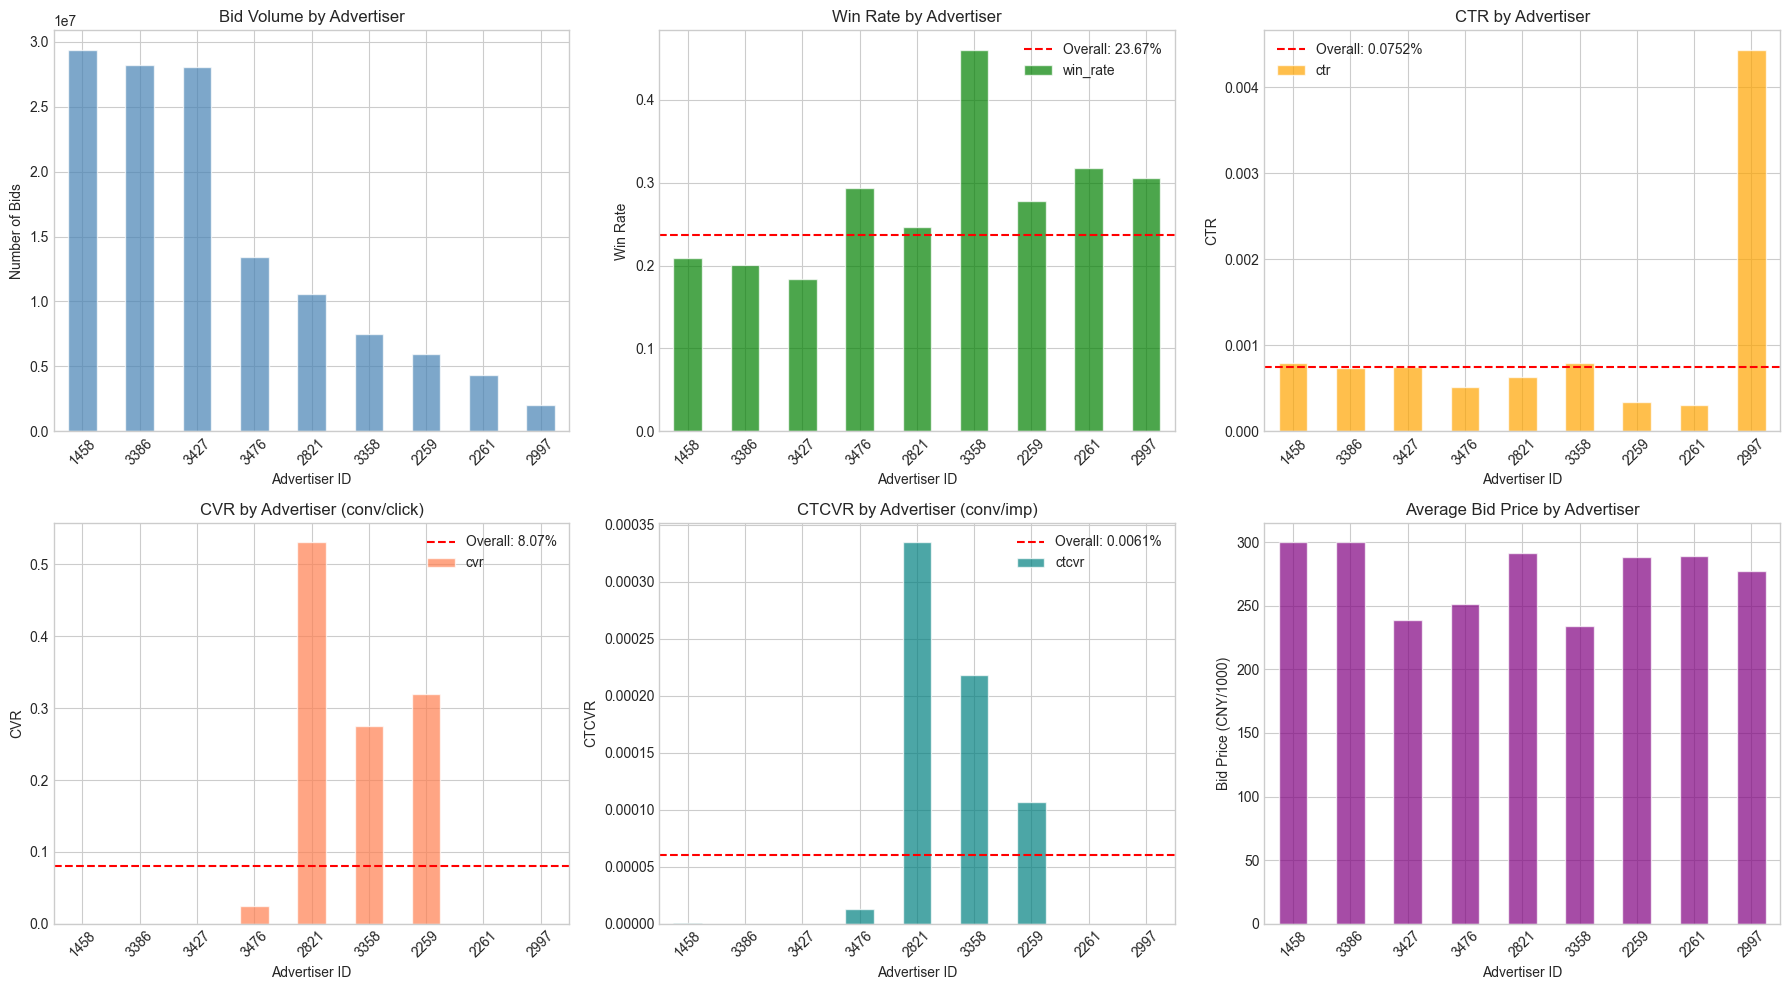

In [8]:
# Campaign statistics visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Bid volume by campaign
ax = axes[0, 0]
campaign_stats['n_bids'].plot(kind='bar', ax=ax, color='steelblue', alpha=0.7)
ax.set_title('Bid Volume by Advertiser')
ax.set_xlabel('Advertiser ID')
ax.set_ylabel('Number of Bids')
ax.tick_params(axis='x', rotation=45)

# 2. Win rate by campaign
ax = axes[0, 1]
campaign_stats['win_rate'].plot(kind='bar', ax=ax, color='green', alpha=0.7)
ax.axhline(y=stats_overall.win_rate, color='red', linestyle='--', label=f'Overall: {stats_overall.win_rate:.2%}')
ax.set_title('Win Rate by Advertiser')
ax.set_xlabel('Advertiser ID')
ax.set_ylabel('Win Rate')
ax.legend()
ax.tick_params(axis='x', rotation=45)

# 3. CTR by campaign
ax = axes[0, 2]
campaign_stats['ctr'].plot(kind='bar', ax=ax, color='orange', alpha=0.7)
ax.axhline(y=stats_overall.ctr, color='red', linestyle='--', label=f'Overall: {stats_overall.ctr:.4%}')
ax.set_title('CTR by Advertiser')
ax.set_xlabel('Advertiser ID')
ax.set_ylabel('CTR')
ax.legend()
ax.tick_params(axis='x', rotation=45)

# 4. CVR by campaign (conv/click)
ax = axes[1, 0]
campaign_stats['cvr'].plot(kind='bar', ax=ax, color='coral', alpha=0.7)
ax.axhline(y=stats_overall.cvr, color='red', linestyle='--', label=f'Overall: {stats_overall.cvr:.2%}')
ax.set_title('CVR by Advertiser (conv/click)')
ax.set_xlabel('Advertiser ID')
ax.set_ylabel('CVR')
ax.legend()
ax.tick_params(axis='x', rotation=45)

# 5. CTCVR by campaign (conv/impression)
ax = axes[1, 1]
campaign_stats['ctcvr'].plot(kind='bar', ax=ax, color='teal', alpha=0.7)
ax.axhline(y=stats_overall.ctcvr, color='red', linestyle='--', label=f'Overall: {stats_overall.ctcvr:.4%}')
ax.set_title('CTCVR by Advertiser (conv/imp)')
ax.set_xlabel('Advertiser ID')
ax.set_ylabel('CTCVR')
ax.legend()
ax.tick_params(axis='x', rotation=45)

# 6. Average bid price by campaign
ax = axes[1, 2]
campaign_stats['avg_bidprice'].plot(kind='bar', ax=ax, color='purple', alpha=0.7)
ax.set_title('Average Bid Price by Advertiser')
ax.set_xlabel('Advertiser ID')
ax.set_ylabel('Bid Price (CNY/1000)')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIG_PATH / '01_eda_campaign_stats.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.1 Conversion Data Sparsity & CVR Near-Trivial

Total conversions: **930 / 15.3M impressions = 0.006%**. This extreme sparsity makes CVR near-trivial:

| Concern | Detail |
|---------|--------|
| **Advertiser 2821: CVR = 53.1%** | 437 conversions / 823 clicks. A 53% post-click CVR is unrealistic for display ads (typical: 1-5%). Likely cause: retargeting artifact (Section 2.2). |
| **Advertiser 3358: CVR = 27.6%** | 377 conversions / 1,367 clicks. Also abnormally high — same retargeting artifact. |
| **5 of 9 advertisers: 0 conversions** | CVR prediction 자체가 불가능. **CTR이 유일한 value signal.** |
| **Only 4 advertisers have ≥26 conversions** | 2821, 3358, 2259, 3476. Even among these, high CVR is retargeting artifact. |

**Implication: CVR near-trivial → Bid→Win→Click pivot**

- CTCVR = 0.006% → conversion은 전체 funnel에서 극소수
- Branding 5개 (CVR=0): CTR prediction만으로 충분
- Retargeting 3개 (CVR=28-53%): click→conv ~1초 retargeting artifact (Section 2.2)
- **핵심 debiasing target: Win Selection Bias** (Bid→Win) → ESMM-WC / ESCM²-WC(DR)
- Value function: **V(x) = debiased_pCTR × CPC_target** (CVR 제거로 단순화)

### 2.2 Conversion Attribution Analysis

Advertiser별 CVR이 27-53%로 비정상적으로 높음. 원인 진단:
1. View-through conversion (click 없이 conversion) 존재 여부
2. Attribution window (imp→click, click→conv 시간) 분포
3. **Bid→Win→Click pivot 근거**: CVR near-trivial 여부 검증

In [9]:
# Step 1: Check funnel consistency — view-through conversions?
conv_mask = df['conversion'] == 1
conv_with_click = (conv_mask & (df['click'] == 1)).sum()
conv_without_click = (conv_mask & (df['click'] == 0)).sum()

print("=== Conversion Attribution Type ===")
print(f"Total conversions:       {conv_mask.sum():,}")
print(f"  Click-through (click=1): {conv_with_click:,} ({conv_with_click/conv_mask.sum():.1%})")
print(f"  View-through  (click=0): {conv_without_click:,} ({conv_without_click/conv_mask.sum():.1%})")

# By advertiser
conv_by_adv = (
    df[conv_mask]
    .groupby('advertiser')
    .agg(**{
        'n_conv': ('conversion', 'sum'),
        'n_conv_with_click': ('click', 'sum'),
    })
    .assign(
        n_conv_view_through=lambda x: x['n_conv'] - x['n_conv_with_click'],
        pct_click_through=lambda x: x['n_conv_with_click'] / x['n_conv'],
    )
)
display(conv_by_adv)

=== Conversion Attribution Type ===
Total conversions:       1,860
  Click-through (click=1): 1,860 (100.0%)
  View-through  (click=0): 0 (0.0%)


,n_conv,n_conv_with_click,n_conv_view_through,pct_click_through
advertiser,,,,
1458,2,2,0,1.0
2259,178,178,0,1.0
2821,874,874,0,1.0
3358,754,754,0,1.0
3476,52,52,0,1.0


In [10]:
# Step 2: Load raw conv/clk logs for timestamp analysis
# Conv logs are tiny (~930 rows), clk logs ~11K rows

raw_dir = DATA_ROOT / 'raw' / 'ipinyou'

# Parse conv/clk logs (bidid + timestamp only)
conv_raw_dfs, clk_raw_dfs = [], []
for season in ['2nd', '3rd']:
    df_conv_raw = parse_season_logs(
        raw_dir, season, 'conv', usecols=['bidid', 'timestamp']
    )
    df_clk_raw = parse_season_logs(
        raw_dir, season, 'clk', usecols=['bidid', 'timestamp']
    )
    conv_raw_dfs.append(
        df_conv_raw.rename(columns={'timestamp': 'conv_ts'})
    )
    clk_raw_dfs.append(
        df_clk_raw.rename(columns={'timestamp': 'clk_ts'})
    )

df_conv_ts = pd.concat(conv_raw_dfs, ignore_index=True)
df_clk_ts = pd.concat(clk_raw_dfs, ignore_index=True)
print(f"Raw conv log rows: {len(df_conv_ts):,}")
print(f"Raw clk log rows:  {len(df_clk_ts):,}")

Found 7 conv files for season 2nd
  [1/7] Parsing conv.20130606.txt.bz2...
  [2/7] Parsing conv.20130607.txt.bz2...
  [3/7] Parsing conv.20130608.txt.bz2...
  [4/7] Parsing conv.20130609.txt.bz2...
  [5/7] Parsing conv.20130610.txt.bz2...
  [6/7] Parsing conv.20130611.txt.bz2...
  [7/7] Parsing conv.20130612.txt.bz2...
  Total rows: 494
Found 7 clk files for season 2nd
  [1/7] Parsing clk.20130606.txt.bz2...
  [2/7] Parsing clk.20130607.txt.bz2...
  [3/7] Parsing clk.20130608.txt.bz2...
  [4/7] Parsing clk.20130609.txt.bz2...
  [5/7] Parsing clk.20130610.txt.bz2...
  [6/7] Parsing clk.20130611.txt.bz2...
  [7/7] Parsing clk.20130612.txt.bz2...
  Total rows: 9,978
Found 5 conv files for season 3rd
  [1/5] Parsing conv.20131019.txt.bz2...
  [2/5] Parsing conv.20131020.txt.bz2...
  [3/5] Parsing conv.20131021.txt.bz2...
  [4/5] Parsing conv.20131022.txt.bz2...
  [5/5] Parsing conv.20131023.txt.bz2...
  Total rows: 539
Found 9 clk files for season 3rd
  [1/9] Parsing clk.20131019.txt.bz2..

In [11]:
# Step 3: Join timestamps and compute time deltas
# bid timestamp (from unified) ≈ impression timestamp (RTB: ms latency)
df_conv_detail = (
    df[df['conversion'] == 1][['bidid', 'timestamp', 'advertiser', 'click']]
    .merge(df_conv_ts, on='bidid', how='left')
    .merge(df_clk_ts, on='bidid', how='left')
)

# Parse timestamps to datetime (format: YYYYMMDDHHMMSSMMM, take first 14 chars)
for col in ['timestamp', 'conv_ts', 'clk_ts']:
    df_conv_detail[f'{col}_dt'] = pd.to_datetime(
        df_conv_detail[col].astype(str).str[:14],
        format='%Y%m%d%H%M%S',
        errors='coerce'
    )

# Time deltas (seconds)
df_conv_detail['imp_to_conv_sec'] = (
    df_conv_detail['conv_ts_dt'] - df_conv_detail['timestamp_dt']
).dt.total_seconds()

df_conv_detail['imp_to_click_sec'] = (
    df_conv_detail['clk_ts_dt'] - df_conv_detail['timestamp_dt']
).dt.total_seconds()

df_conv_detail['click_to_conv_sec'] = (
    df_conv_detail['conv_ts_dt'] - df_conv_detail['clk_ts_dt']
).dt.total_seconds()

# Summary stats
print("=== Attribution Window Statistics (seconds) ===")
for col, label in [
    ('imp_to_click_sec', 'Impression → Click'),
    ('click_to_conv_sec', 'Click → Conversion'),
    ('imp_to_conv_sec', 'Impression → Conversion'),
]:
    valid = df_conv_detail[col].dropna()
    if len(valid) > 0:
        print(f"\n{label} (n={len(valid):,}):")
        print(f"  Median: {valid.median():,.0f}s ({valid.median()/3600:.1f}h)")
        print(f"  Mean:   {valid.mean():,.0f}s ({valid.mean()/3600:.1f}h)")
        print(f"  P25:    {valid.quantile(0.25):,.0f}s")
        print(f"  P75:    {valid.quantile(0.75):,.0f}s")
        print(f"  P95:    {valid.quantile(0.95):,.0f}s")
        print(f"  Max:    {valid.max():,.0f}s ({valid.max()/86400:.1f}d)")
    else:
        print(f"\n{label}: No valid data (0 matches)")

# Join rate
n_conv_total = len(df_conv_detail)
n_conv_ts_matched = df_conv_detail['conv_ts'].notna().sum()
n_clk_ts_matched = df_conv_detail['clk_ts'].notna().sum()
print(f"\n=== Join Rates ===")
print(f"Conv timestamp matched: {n_conv_ts_matched:,}/{n_conv_total:,} ({n_conv_ts_matched/n_conv_total:.1%})")
print(f"Click timestamp matched: {n_clk_ts_matched:,}/{n_conv_total:,} ({n_clk_ts_matched/n_conv_total:.1%})")

=== Attribution Window Statistics (seconds) ===

Impression → Click (n=2,644):
  Median: 12s (0.0h)
  Mean:   243s (0.1h)
  P25:    1s
  P75:    111s
  P95:    1,084s
  Max:    26,364s (0.3d)

Click → Conversion (n=2,644):
  Median: 1s (0.0h)
  Mean:   152s (0.0h)
  P25:    0s
  P75:    10s
  P95:    51s
  Max:    26,187s (0.3d)

Impression → Conversion (n=2,644):
  Median: 20s (0.0h)
  Mean:   395s (0.1h)
  P25:    1s
  P75:    119s
  P95:    1,213s
  Max:    26,403s (0.3d)

=== Join Rates ===
Conv timestamp matched: 2,644/2,644 (100.0%)
Click timestamp matched: 2,644/2,644 (100.0%)


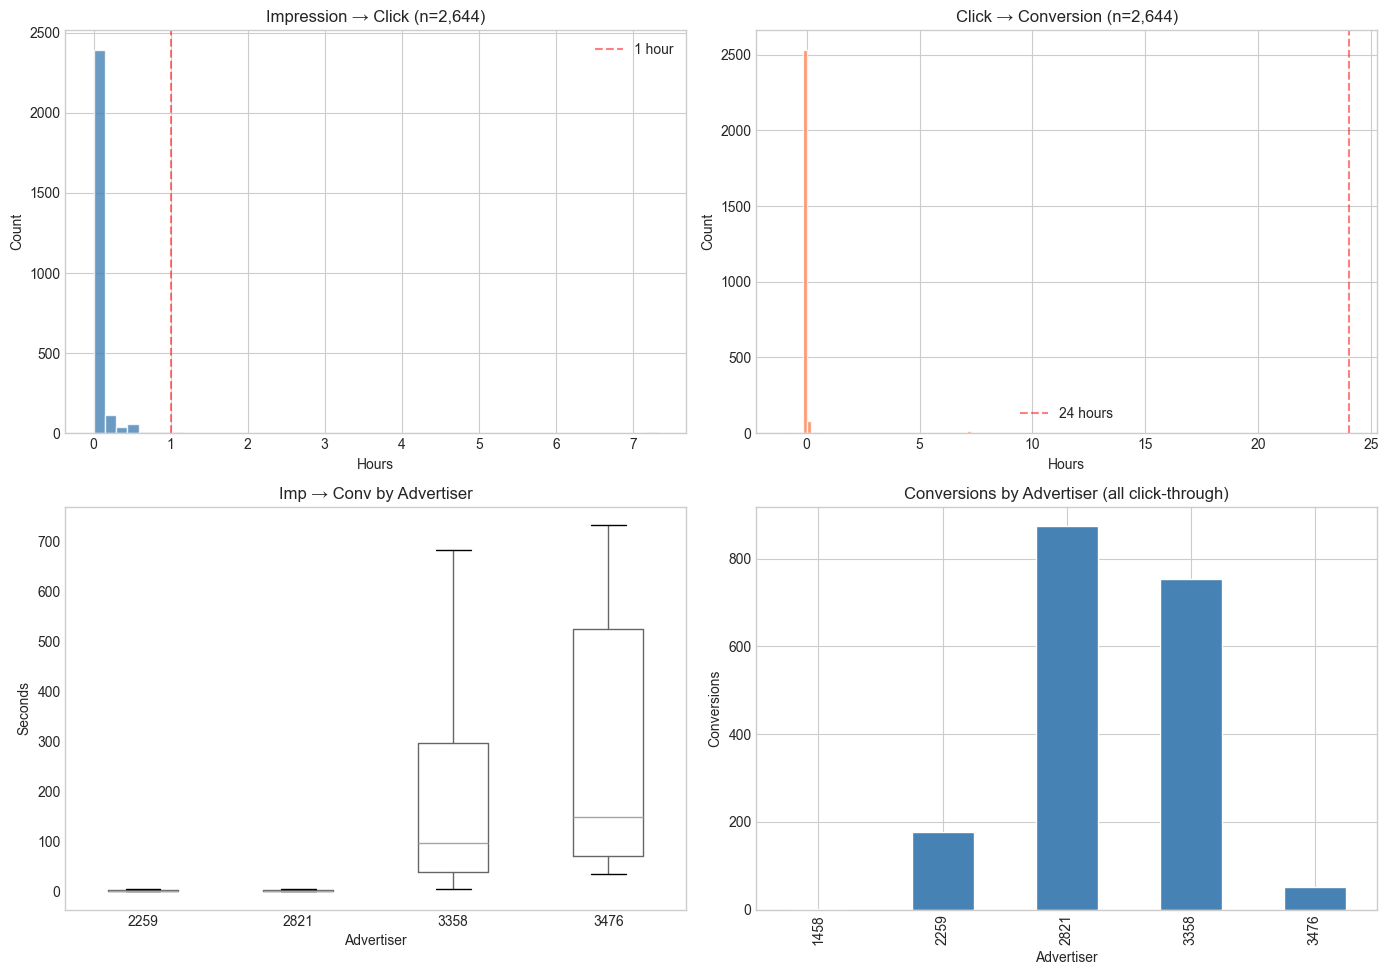

In [12]:
# Step 4: Visualize attribution windows
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 4a. Imp → Click time (hours)
ax = axes[0, 0]
valid_i2c = df_conv_detail['imp_to_click_sec'].dropna()
if len(valid_i2c) > 0:
    ax.hist(valid_i2c / 3600, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_xlabel('Hours')
    ax.set_ylabel('Count')
    ax.set_title(f'Impression → Click (n={len(valid_i2c):,})')
    ax.axvline(x=1, color='red', linestyle='--', alpha=0.5, label='1 hour')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'No click timestamps matched', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Impression → Click')

# 4b. Click → Conversion time (hours)
ax = axes[0, 1]
valid_c2c = df_conv_detail['click_to_conv_sec'].dropna()
if len(valid_c2c) > 0:
    ax.hist(valid_c2c / 3600, bins=50, color='coral', edgecolor='white', alpha=0.8)
    ax.set_xlabel('Hours')
    ax.set_ylabel('Count')
    ax.set_title(f'Click → Conversion (n={len(valid_c2c):,})')
    ax.axvline(x=24, color='red', linestyle='--', alpha=0.5, label='24 hours')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'No click→conv timestamps matched', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Click → Conversion')

# 4c. Imp → Conversion by advertiser (boxplot)
ax = axes[1, 0]
conv_adv = df_conv_detail.dropna(subset=['imp_to_conv_sec'])
if len(conv_adv) > 0:
    advs_with_conv = (
        conv_adv.groupby('advertiser')
        .filter(lambda x: len(x) >= 5)['advertiser']
        .unique()
    )
    conv_adv_filtered = conv_adv[conv_adv['advertiser'].isin(advs_with_conv)]
    if len(conv_adv_filtered) > 0:
        conv_adv_filtered.boxplot(
            column='imp_to_conv_sec', by='advertiser', ax=ax,
            showfliers=False, grid=False
        )
        ax.set_xlabel('Advertiser')
        ax.set_ylabel('Seconds')
        ax.set_title('Imp → Conv by Advertiser')
        plt.suptitle('')
    else:
        ax.text(0.5, 0.5, 'Not enough data per advertiser', ha='center', va='center', transform=ax.transAxes)
        ax.set_title('Imp → Conv by Advertiser')
else:
    ax.text(0.5, 0.5, 'No imp→conv timestamps matched', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Imp → Conv by Advertiser')

# 4d. Attribution type by advertiser (stacked bar)
ax = axes[1, 1]
if conv_without_click > 0:
    conv_by_adv[['n_conv_with_click', 'n_conv_view_through']].plot(
        kind='bar', stacked=True, ax=ax, color=['steelblue', 'coral']
    )
    ax.set_xlabel('Advertiser')
    ax.set_ylabel('Conversions')
    ax.set_title('Click-through vs View-through by Advertiser')
    ax.legend(['Click-through', 'View-through'])
else:
    # All click-through: show conversion counts by advertiser
    df[df['conversion'] == 1].groupby('advertiser').size().plot(
        kind='bar', ax=ax, color='steelblue'
    )
    ax.set_xlabel('Advertiser')
    ax.set_ylabel('Conversions')
    ax.set_title('Conversions by Advertiser (all click-through)')

plt.tight_layout()
plt.savefig(str(FIG_PATH / '01_eda_conversion_attribution.png'), dpi=150, bbox_inches='tight')
plt.show()

### 2.2.1 Findings

**핵심 발견: Retargeting Campaign의 강력한 증거**

| Metric | Value | Normal Display Ad Range |
|--------|-------|------------------------|
| View-through conversion | **0건 (100% click-through)** | 20-60% view-through |
| Click → Conversion median | **~1초** | 분~시간 단위 |
| Imp → Click median | **~12초** | 30초~수 분 |
| Advertiser 2821 CVR | **53%** | 0.5-3% |
| Advertiser 3358 CVR | **28%** | 0.5-3% |

100% click-through attribution + click→conv **1초 전환**은 일반 display ad에서 사실상 불가능. 이는 **사전 전환 의도가 있는 유저를 re-targeting**한 것을 강력히 시사:
- 일반 display ad의 click→conv은 분~시간 단위가 정상; 1초 전환은 이미 장바구니에 상품이 있거나 결제 직전 단계의 유저
- Advertiser 2821 (CVR 53%), 3358 (28%)의 비정상 CVR도 retargeting으로 설명 가능 — 이미 관심이 있는 유저에게 광고를 보여 높은 전환율 달성
- Imp→Click median 12초도 비정상적으로 짧음 → landing page = conversion page (1-click purchase) 또는 auto-redirect 가능성

**Bid→Win→Click Pivot 결론:**
1. **CVR near-trivial**: Branding 5개 CVR=0, Retargeting 3개 artifact → CVR 예측 가치 제한적
2. **CTR이 핵심 value signal**: 모든 advertiser에서 V(x) = debiased_pCTR × CPC_target
3. **Win Selection Bias가 primary debiasing target**: ESMM-WC / ESCM²-WC(DR)로 해결
4. **Advertiser를 반드시 stratification 변수로 포함** — retargeting 강도가 광고주마다 다르며 CTR 패턴에 직접 영향
5. Retargeting flag (prior visit/cart history) 피처 검토 — 데이터에서 직접 확인 불가하나, usertag에 일부 반영 가능성

In [ ]:
# 2.3 CTR as Primary Value Signal

ctr_analysis = campaign_stats.copy()
ctr_analysis['segment'] = ctr_analysis.index.map(
    lambda a: next((s for s, advs in ADVERTISER_TAXONOMY.items() if int(a) in advs), 'unknown')
)

# 1. CTR vs CVR comparison: CTR consistent, CVR bifurcated
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: CTR by advertiser (consistent across all)
seg_colors = SEG_COLORS
ax = axes[0]
for _, row in ctr_analysis.iterrows():
    color = seg_colors.get(row['segment'], 'gray')
    ax.barh(str(int(row.name)), row['ctr'] * 100, color=color, alpha=0.8)
ax.set_xlabel('CTR (%)')
ax.set_title('CTR by Advertiser (Won Impressions)')
ax.legend(handles=[Patch(color=c, label=s) for s, c in seg_colors.items()])

# Panel 2: CVR by advertiser (bifurcated: 0 vs artifact)
ax = axes[1]
for _, row in ctr_analysis.iterrows():
    color = seg_colors.get(row['segment'], 'gray')
    ax.barh(str(int(row.name)), row['cvr'] * 100, color=color, alpha=0.8)
ax.set_xlabel('CVR (%)')
ax.set_title('CVR by Advertiser — Bifurcated')

# Panel 3: Population-level CTR (= Win Rate × CTR)
# 정의: 전체 입찰(bid) 모집단 기준 CTR. P(click|bid) = P(win|bid) × P(click|win)
ctr_analysis['population_ctr'] = ctr_analysis['win_rate'] * ctr_analysis['ctr']
ax = axes[2]
for _, row in ctr_analysis.iterrows():
    color = seg_colors.get(row['segment'], 'gray')
    ax.barh(str(int(row.name)), row['population_ctr'] * 10000, color=color, alpha=0.8)
ax.set_xlabel('Bid-level CTR (per 10K bids)')
ax.set_title('Population-level CTR = Win Rate × CTR\n(P(click|bid))')

plt.tight_layout()
plt.savefig(FIG_PATH / '01_eda_ctr_value_signal.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Summary table
print("CTR vs CVR: Value Signal Comparison")
print("=" * 90)
display(
    ctr_analysis[['segment', 'n_bids', 'n_wins', 'win_rate', 'ctr', 'cvr', 'ctcvr', 'population_ctr']]
    .sort_values('n_bids', ascending=False)
    .round(6)
)

# 3. Key statistics
overall_ctr = campaign_stats['n_clicks'].sum() / campaign_stats['n_wins'].sum()
overall_cvr = campaign_stats['n_conversions'].sum() / max(campaign_stats['n_clicks'].sum(), 1)
overall_ctcvr = campaign_stats['n_conversions'].sum() / campaign_stats['n_wins'].sum()
branding_clicks = ctr_analysis[ctr_analysis['segment'] == 'branding']['n_clicks'].sum()
total_clicks = campaign_stats['n_clicks'].sum()

print(f"\nKey Statistics:")
print(f"  Overall CTR (won impressions): {overall_ctr:.4%}")
print(f"  Overall CVR: {overall_cvr:.4%}")
print(f"  Overall CTCVR: {overall_ctcvr:.6%}")
print(f"  Branding clicks / Total: {branding_clicks:,} / {total_clicks:,} = {branding_clicks/total_clicks:.1%}")
print(f"\n→ CTR is universal value signal across ALL advertiser segments")
print(f"→ CVR is near-trivial (CTCVR {overall_ctcvr:.4%}) → excluded from modeling target")

### 2.3 CTR as Primary Value Signal

**Section 2.1-2.2 요약**: CVR은 near-trivial (CTCVR 0.006%, branding CVR=0, retargeting artifact).
이 섹션에서는 CTR이 **모든 advertiser에서 유효한 primary value signal**임을 보여줌.

**CTR vs CVR 비교:**

| Metric | CTR (Click/Impression) | CVR (Conv/Click) |
|--------|----------------------|-------------------|
| 유효 advertiser | **9/9 (100%)** | 4/9 (44%, 이 중 3개는 artifact) |
| 분포 | 0.01-0.35% 범위, 연속적 | 양극화: 0% vs 28-53% |
| 예측 가치 | 모든 advertiser에서 bid value 결정 | 제한적 (branding 불가, retargeting artifact) |
| Debiasing 필요성 | **Win Selection Bias로 +6.7% 왜곡** (NB02) | Near-trivial → debiasing 우선순위 낮음 |

**Population-level CTR** (Bid-level CTR): 전체 입찰 모집단 기준 CTR.
- **정의**: P(click|bid) = P(win|bid) × P(click|win) = Win Rate × CTR
- Win rate가 낮은 advertiser일수록 경쟁이 치열하여 bid당 클릭 획득 확률 하락
- 이는 bid optimization의 직접적 동기: **동일 CTR이라도 win rate를 높여 population-level CTR 개선**
- V(x) = debiased_pCTR × CPC_target → Win Selection Bias 제거 시 pCTR 정확도 향상 → 입찰 효율 개선

**결론**:
- CTR은 모든 advertiser에 적용 가능한 **universal value signal**
- CVR은 near-trivial → 모델링 대상에서 제외
- **Bid→Win→Click**: Win Selection Bias 해결(ESMM-WC / ESCM²-WC(DR))이 CTR 예측 정확도와 bid value에 직접 기여

## 3. Win Rate Distribution

Analyze win rate by different dimensions.

In [14]:
# Add hour column if not present
if 'hour' not in df.columns:
    df['hour'] = df['timestamp'].astype(str).str[8:10].astype(int)

# Add slot_size column
if 'slot_size' not in df.columns:
    df['slot_size'] = df['slotwidth'].astype(str) + 'x' + df['slotheight'].astype(str)

# Bid price bucket (needed for bid_bucket groupby)
df['bid_bucket'] = pd.qcut(df['bidprice'], q=10, labels=False, duplicates='drop')

# Run 6 independent groupbys in parallel using ThreadPoolExecutor
vis_labels = VIS_LABELS

gb_specs = [
    GroupbySpec(
        name='hourly',
        by='hour',
        agg_spec=dict(n_bids=('bidid', 'count'), n_wins=('win', 'sum')),
        post_fn=lambda x: x.assign(win_rate=lambda x: x['n_wins'] / x['n_bids']),
    ),
    GroupbySpec(
        name='exchange',
        by='adexchange',
        agg_spec=dict(n_bids=('bidid', 'count'), n_wins=('win', 'sum')),
        post_fn=lambda x: x.assign(win_rate=lambda x: x['n_wins'] / x['n_bids']),
    ),
    GroupbySpec(
        name='bid_bucket',
        by='bid_bucket',
        agg_spec=dict(n_bids=('bidid', 'count'), n_wins=('win', 'sum'), avg_bid=('bidprice', 'mean')),
        post_fn=lambda x: x.assign(win_rate=lambda x: x['n_wins'] / x['n_bids']),
    ),
    GroupbySpec(
        name='visibility',
        by='slotvisibility',
        agg_spec=dict(n_bids=('bidid', 'count'), n_wins=('win', 'sum')),
        post_fn=lambda x: x.assign(win_rate=lambda x: x['n_wins'] / x['n_bids']).rename(index=vis_labels),
    ),
    GroupbySpec(
        name='slot_size',
        by='slot_size',
        agg_spec=dict(n_bids=('bidid', 'count'), n_wins=('win', 'sum')),
        post_fn=lambda x: x.assign(win_rate=lambda x: x['n_wins'] / x['n_bids']),
        sort_by='n_bids',
        head_n=10,
    ),
    GroupbySpec(
        name='advertiser',
        by='advertiser',
        agg_spec=dict(n_bids=('bidid', 'count'), n_wins=('win', 'sum')),
        post_fn=lambda x: x.assign(win_rate=lambda x: x['n_wins'] / x['n_bids']),
        sort_by='n_bids',
    ),
]

gb = parallel_groupbys(df, gb_specs)
hourly_stats = gb.results['hourly']
exchange_stats = gb.results['exchange']
bid_bucket_stats = gb.results['bid_bucket']
visibility_stats = gb.results['visibility']
slot_win_stats = gb.results['slot_size']
adv_win_stats = gb.results['advertiser']

print("Win Rate by Dimension:")
print(f"  Hour range:       {hourly_stats['win_rate'].min():.2%} ~ {hourly_stats['win_rate'].max():.2%}")
print(f"  Exchange range:   {exchange_stats['win_rate'].min():.2%} ~ {exchange_stats['win_rate'].max():.2%}")
print(f"  Visibility range: {visibility_stats['win_rate'].min():.2%} ~ {visibility_stats['win_rate'].max():.2%}")
print(f"  Slot size range:  {slot_win_stats['win_rate'].min():.2%} ~ {slot_win_stats['win_rate'].max():.2%}")
print(f"  Advertiser range: {adv_win_stats['win_rate'].min():.2%} ~ {adv_win_stats['win_rate'].max():.2%}")

Win Rate by Dimension:
  Hour range:       8.59% ~ 43.06%
  Exchange range:   13.24% ~ 55.55%
  Visibility range: 16.54% ~ 61.73%
  Slot size range:  14.74% ~ 57.16%
  Advertiser range: 18.40% ~ 46.06%


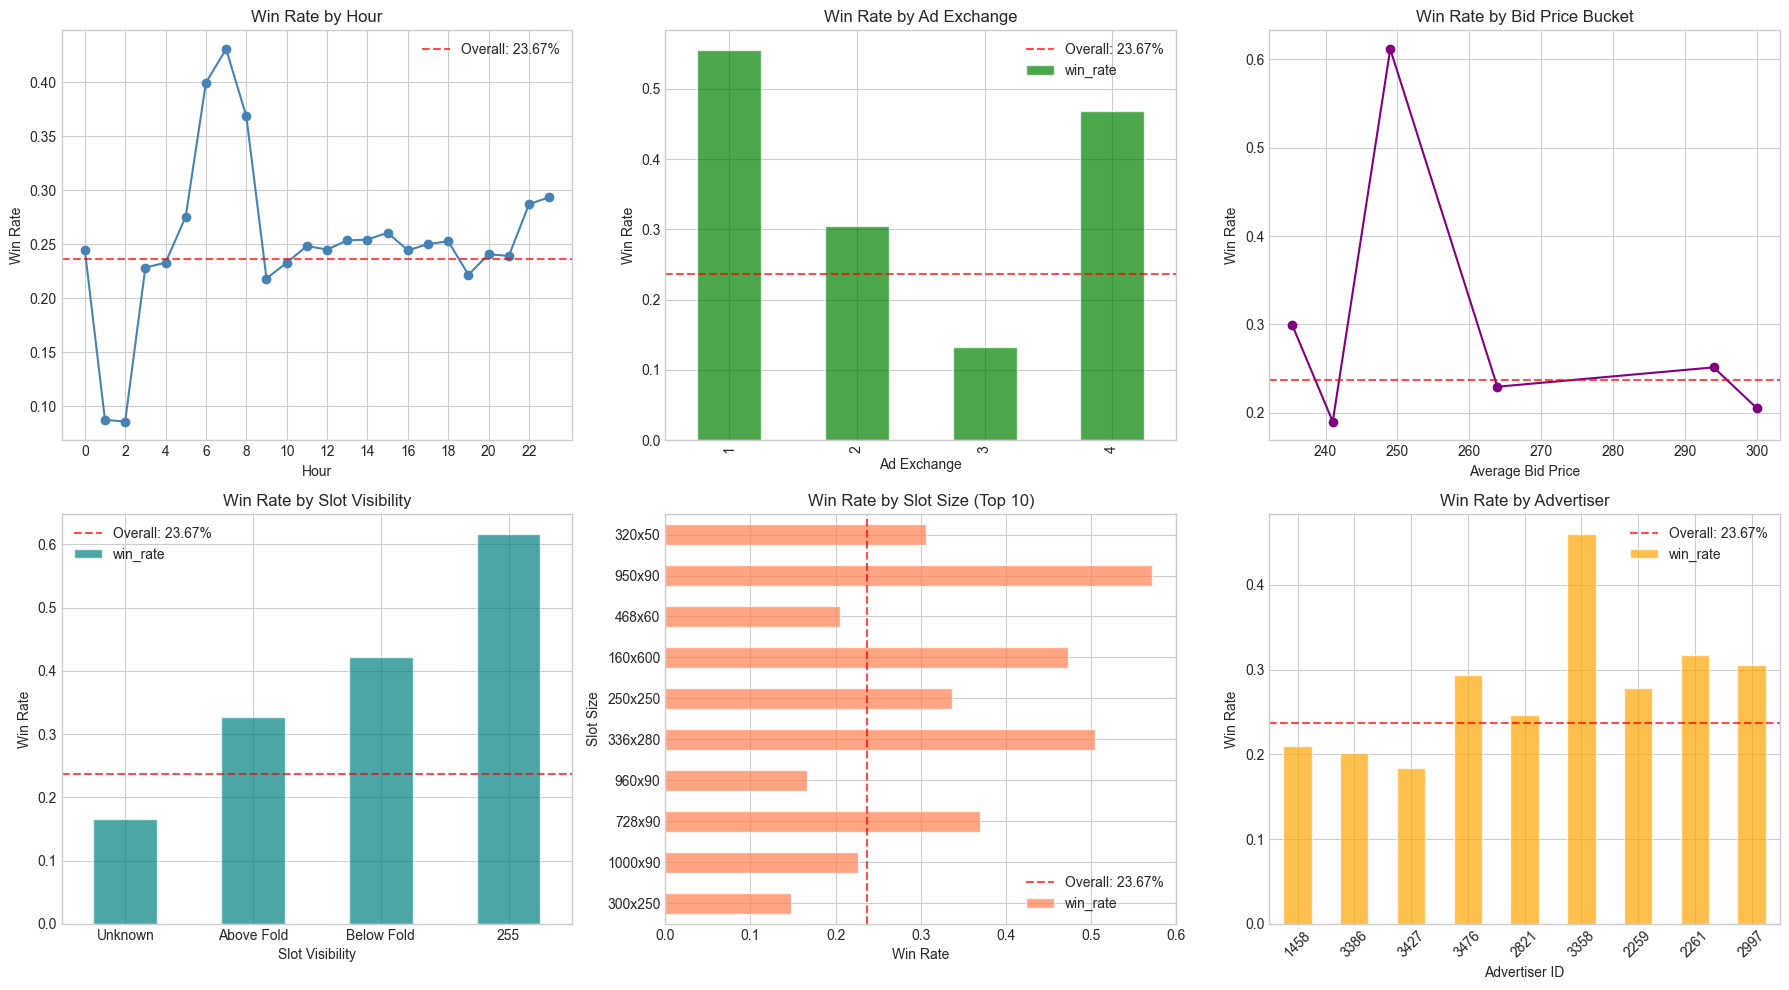

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
overall_wr = stats_overall.win_rate

# 1. Win rate by hour
ax = axes[0, 0]
ax.plot(hourly_stats.index, hourly_stats['win_rate'], 'o-', color='steelblue')
ax.axhline(y=overall_wr, color='red', linestyle='--', alpha=0.7, label=f'Overall: {overall_wr:.2%}')
ax.set_xlabel('Hour')
ax.set_ylabel('Win Rate')
ax.set_title('Win Rate by Hour')
ax.set_xticks(range(0, 24, 2))
ax.legend()

# 2. Win rate by ad exchange
ax = axes[0, 1]
exchange_stats['win_rate'].plot(kind='bar', ax=ax, color='green', alpha=0.7)
ax.axhline(y=overall_wr, color='red', linestyle='--', alpha=0.7, label=f'Overall: {overall_wr:.2%}')
ax.set_xlabel('Ad Exchange')
ax.set_ylabel('Win Rate')
ax.set_title('Win Rate by Ad Exchange')
ax.legend()

# 3. Win rate by bid price bucket
ax = axes[0, 2]
ax.plot(bid_bucket_stats['avg_bid'], bid_bucket_stats['win_rate'], 'o-', color='purple')
ax.axhline(y=overall_wr, color='red', linestyle='--', alpha=0.7)
ax.set_xlabel('Average Bid Price')
ax.set_ylabel('Win Rate')
ax.set_title('Win Rate by Bid Price Bucket')

# 4. Win rate by slot visibility
ax = axes[1, 0]
visibility_stats['win_rate'].plot(kind='bar', ax=ax, color='teal', alpha=0.7)
ax.axhline(y=overall_wr, color='red', linestyle='--', alpha=0.7, label=f'Overall: {overall_wr:.2%}')
ax.set_xlabel('Slot Visibility')
ax.set_ylabel('Win Rate')
ax.set_title('Win Rate by Slot Visibility')
ax.legend()
ax.tick_params(axis='x', rotation=0)

# 5. Win rate by slot size (top 10)
ax = axes[1, 1]
slot_win_stats['win_rate'].plot(kind='barh', ax=ax, color='coral', alpha=0.7)
ax.axvline(x=overall_wr, color='red', linestyle='--', alpha=0.7, label=f'Overall: {overall_wr:.2%}')
ax.set_xlabel('Win Rate')
ax.set_ylabel('Slot Size')
ax.set_title('Win Rate by Slot Size (Top 10)')
ax.legend()

# 6. Win rate by advertiser
ax = axes[1, 2]
adv_win_stats['win_rate'].plot(kind='bar', ax=ax, color='orange', alpha=0.7)
ax.axhline(y=overall_wr, color='red', linestyle='--', alpha=0.7, label=f'Overall: {overall_wr:.2%}')
ax.set_xlabel('Advertiser ID')
ax.set_ylabel('Win Rate')
ax.set_title('Win Rate by Advertiser')
ax.legend()
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIG_PATH / '01_eda_win_rate.png', dpi=150, bbox_inches='tight')
plt.show()

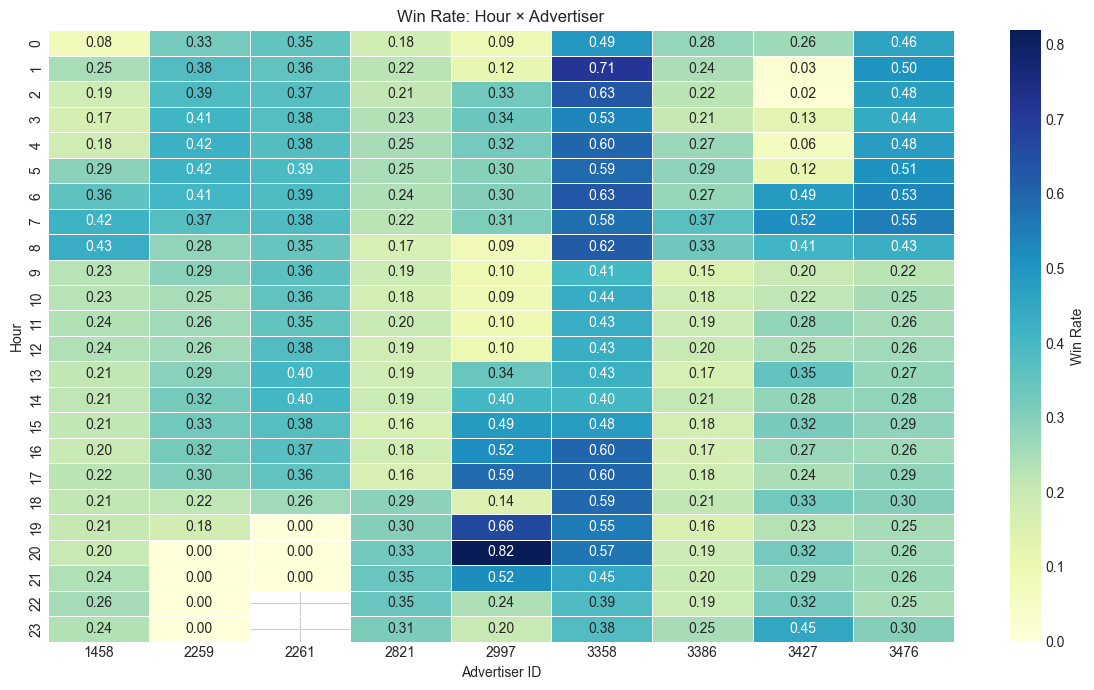

In [16]:
# Win rate heatmap: Hour × Advertiser
hour_adv_wr = (
    df.groupby(['hour', 'advertiser'])
    .agg(n_bids=('bidid', 'count'), n_wins=('win', 'sum'))
    .assign(win_rate=lambda x: x['n_wins'] / x['n_bids'])
    ['win_rate']
    .unstack('advertiser')
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(hour_adv_wr, annot=True, fmt='.2f', cmap='YlGnBu', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Win Rate'})
ax.set_title('Win Rate: Hour × Advertiser')
ax.set_xlabel('Advertiser ID')
ax.set_ylabel('Hour')

plt.tight_layout()
plt.savefig(FIG_PATH / '01_eda_win_rate_hour_advertiser.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.1 Win Rate — Interpretation

**시간대별 win rate 변동 (8.6%~43.1%)이 Flat-bid 전략의 비효율을 직접 보여줌:**
- 야간(새벽): 경쟁 낮음 → win rate 40%+ (동일 bid로 쉽게 낙찰)
- 주간(오후): 경쟁 높음 → win rate ~10% (같은 bid로 대부분 실패)
- 동일 flat-bid 300 CPM으로 새벽에는 과잉 지불, 오후에는 낙찰 기회 상실 → **시간대별 bid 조정 필수**

**Exchange별 win rate 차이 (13%~56%):**
- Inventory quality + floor price 메커니즘 차이 반영
- Exchange 1 (no floor): 순수 경쟁 기반 → 낮은 win rate 가능
- Exchange 3 (active floor ~66 CPM): floor 이상만 입찰 → floor > 경쟁 bid인 경우 높은 win rate

**Bid bucket별 win rate (우상):**
- Bid가 높을수록 win rate 단조 증가 → bid_floor_ratio가 win propensity의 핵심 driver
- 이 단조 관계가 Win Tower 학습의 근거: P(Win | X, bid)는 bid에 대해 monotonic

**Slot visibility별 win rate:**
- Above fold (visibility=1) vs below fold: win rate 차이 존재
- 가시성 높은 슬롯일수록 경쟁 치열 → win rate 변동

**Slot size별 win rate:**
- IAB 표준 크기별 win rate 상이 (14.7%~57.2%)
- Medium rectangle (300x250) 등 인기 크기는 경쟁 높음

**Advertiser별 win rate:**
- Advertiser 간 win rate 2-5x 차이 → bid 수준 + 타겟 인벤토리 품질 차이

**Hour × Advertiser heatmap:**
- 동일 시간대에서도 advertiser간 win rate 2-5x 차이 → advertiser별 bid 수준 + 타겟 인벤토리 품질 차이
- Flat-bid의 한계를 시각적으로 확인: 일정한 bid로 시간/exchange/인벤토리 조건이 다른 옥션에 입찰

**Bid Optimization 시사점:** `hour` + `adexchange`를 bid shading factor로 반드시 포함. 이 두 변수만으로도 win rate 4-5x 변동 설명 가능.

## 4. Pricing & Auction Mechanics

Analyze the relationship between bid price and market clearing price (payprice).

In [17]:
# Filter to won bids only (payprice available)
df_won = df[df['win'] == 1].copy()
print(f"Won bids: {len(df_won):,}")

# Compute bid-pay spread
df_won['bid_pay_spread'] = df_won['bidprice'] - df_won['payprice']
df_won['bid_pay_ratio'] = df_won['bidprice'] / df_won['payprice'].replace(0, 1)

print(f"\nBid-Pay Spread Statistics:")
print(f"  Mean spread: {df_won['bid_pay_spread'].mean():.2f}")
print(f"  Median spread: {df_won['bid_pay_spread'].median():.2f}")
print(f"  Mean ratio: {df_won['bid_pay_ratio'].mean():.2f}")

Won bids: 30,645,316

Bid-Pay Spread Statistics:
  Mean spread: 192.28
  Median spread: 208.00
  Mean ratio: 8.15


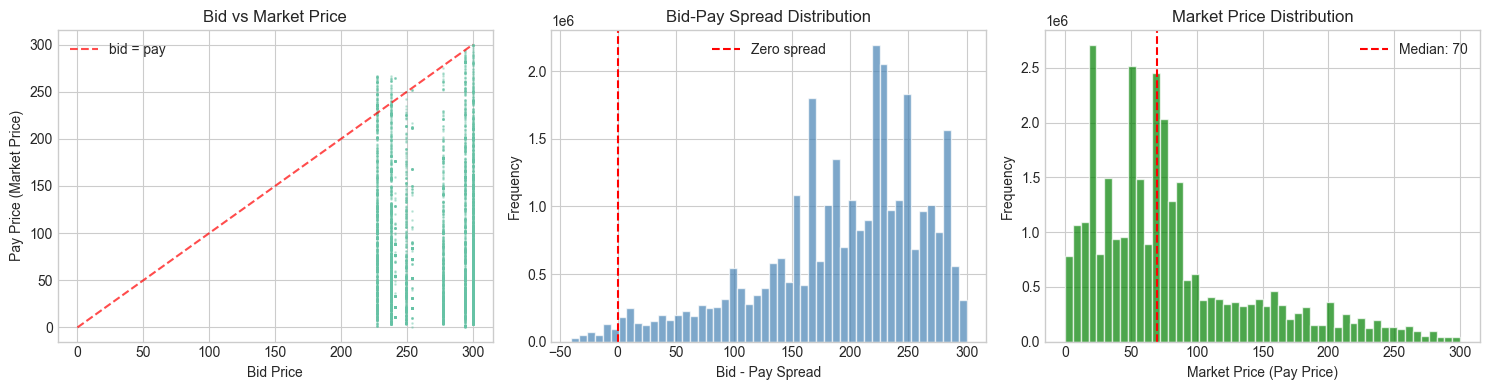

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Bid vs Pay scatter (sample)
ax = axes[0]
sample = df_won.sample(min(10000, len(df_won)), random_state=42)
ax.scatter(sample['bidprice'], sample['payprice'], alpha=0.3, s=1)
max_val = max(sample['bidprice'].max(), sample['payprice'].max())
ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.7, label='bid = pay')
ax.set_xlabel('Bid Price')
ax.set_ylabel('Pay Price (Market Price)')
ax.set_title('Bid vs Market Price')
ax.legend()

# 2. Spread distribution
ax = axes[1]
spread_clipped = df_won['bid_pay_spread'].clip(-100, 500)
ax.hist(spread_clipped, bins=50, alpha=0.7, color='steelblue', edgecolor='white')
ax.axvline(x=0, color='red', linestyle='--', label='Zero spread')
ax.set_xlabel('Bid - Pay Spread')
ax.set_ylabel('Frequency')
ax.set_title('Bid-Pay Spread Distribution')
ax.legend()

# 3. Market price distribution
ax = axes[2]
pay_clipped = df_won['payprice'].clip(0, 500)
ax.hist(pay_clipped, bins=50, alpha=0.7, color='green', edgecolor='white')
ax.axvline(x=df_won['payprice'].median(), color='red', linestyle='--', 
           label=f'Median: {df_won["payprice"].median():.0f}')
ax.set_xlabel('Market Price (Pay Price)')
ax.set_ylabel('Frequency')
ax.set_title('Market Price Distribution')
ax.legend()

plt.tight_layout()
plt.savefig(FIG_PATH / '01_eda_bid_market_price.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.0 Bid vs Market Price — Interpretation

**좌 (Bid vs Pay Price 산점도):**
- 모든 점이 `bid = pay` 대각선 아래 → `payprice ≤ bidprice` 항상 성립 (second-price 특성)
- bidprice 230~300 부근에 수직 밀집 → iPinYou가 소수의 고정 bidprice 사용 (flat-bid 전략)
- 대부분의 payprice는 0~150 CPM → 높은 surplus (bid 대비 저가 낙찰)

**중 (Bid-Pay Spread 분포):**
- Mean spread 192 CPM, median 208 CPM → 대부분의 낙찰에서 큰 surplus 확보
- 분포가 100~300 CPM에 넓게 퍼짐 → iPinYou가 시장가 대비 상당히 공격적으로 overbid
- Second-price이므로 surplus는 DSP(iPinYou)에게 귀속 — 문제 아님
- **First-price 전환 시 이 spread 전체가 과잉 지불로 전환** → bid shading의 존재 이유

**우 (Market Price 분포):**
- Median 70 CPM, 강한 right-skew → 대부분의 경매는 저가에 낙찰
- bidprice ~292 대비 market price median 70 → bid-to-pay ratio 평균 8.15x
- 이 분포가 Win Tower가 추정해야 할 market price CDF의 ground truth (censored)

In [19]:
# 4.1 Flat-Bid Strategy Detection & Second-Price Auction Context
# Compute bid price statistics by advertiser to quantify bidding strategy
bid_strategy = (
    df.groupby('advertiser')['bidprice']
    .agg(['mean', 'std', 'min', 'max', 'median'])
    .assign(
        cv=lambda x: x['std'] / x['mean'],  # coefficient of variation
        is_flat=lambda x: x['cv'] < 0.01,    # flat if CV < 1%
    )
    .sort_values('mean', ascending=False)
)

print("=== Bid Price Statistics by Advertiser ===")
display(bid_strategy.round(2))

n_flat = bid_strategy['is_flat'].sum()
n_near_flat = (bid_strategy['cv'] < 0.05).sum()
print(f"\nFlat-bid advertisers (CV < 1%): {n_flat}/{len(bid_strategy)}")
print(f"Near-flat (CV < 5%): {n_near_flat}/{len(bid_strategy)}")

# Potential savings under first-price: if flat-bidding at 300 but market median is 70
median_market = df_won['payprice'].median()
mean_flat_bid = bid_strategy.loc[bid_strategy['is_flat'], 'mean'].mean()
if not np.isnan(mean_flat_bid):
    savings_pct = (mean_flat_bid - median_market) / mean_flat_bid * 100
    print(f"\nFlat-bid baseline inefficiency (second-price context):")
    print(f"  Avg flat bid: {mean_flat_bid:.0f} CPM")
    print(f"  Median market price: {median_market:.0f} CPM")
    print(f"  Under first-price, flat-bid would overpay by ~{savings_pct:.0f}%")

=== Bid Price Statistics by Advertiser ===


,mean,std,min,max,median,cv,is_flat
advertiser,,,,,,,
1458,300.0,0.0,300,300,300.0,0.0,True
3386,300.0,0.0,300,300,300.0,0.0,True
2821,291.33,6.19,277,294,294.0,0.02,False
2261,288.87,7.8,277,294,294.0,0.03,False
2259,288.15,8.08,277,294,294.0,0.03,False
2997,277.0,0.0,277,277,277.0,0.0,True
3476,250.91,5.57,238,254,254.0,0.02,False
3427,238.34,3.65,227,241,238.0,0.02,False
3358,233.76,6.31,227,241,238.0,0.03,False



Flat-bid advertisers (CV < 1%): 3/9
Near-flat (CV < 5%): 9/9

Flat-bid baseline inefficiency (second-price context):
  Avg flat bid: 292 CPM
  Median market price: 70 CPM
  Under first-price, flat-bid would overpay by ~76%


### 4.1 Bid Strategy & Auction Context

**Finding: Flat-Bid Strategies**

Most advertisers use fixed or near-fixed bidding (bid price CV < 1-5%). This reflects the **2013 RTB market** where value-based bidding was immature. The flat-bid is the natural baseline against which bid optimization improvement should be measured.

**Auction Type: Second-Price (2013)**

The iPinYou dataset is from 2013 when **second-price auctions** dominated RTB:
- Winner pays the second-highest bid (or floor price), not their own bid
- The 8.15x mean bid/pay ratio is **not overbidding** — it's the expected outcome of flat-bid (300 CPM) + second-price + low-competition inventory (median market ~70 CPM)
- Under second-price, there is no penalty for bidding above market price — you always pay market price if you win
- The `payprice` field represents the **market competition level** (second-highest bid or floor), not what a first-price bidder would pay

**Implications for First-Price Bid Optimization (project goal):**
- The payprice distribution serves as a **market price CDF estimate** — the foundation for bid shading
- Under first-price, the same flat-bid strategy would result in ~70% budget waste (paying 300 when market is 70)
- The bid-pay spread (~192 CPM) represents the **upper bound of potential savings** from bid shading
- Exchange-level floor price mechanisms differ (Exchange 1: no floor vs Exchange 3: active floor) — bid shading strategy must be exchange-aware

**Flat-bid 비효율의 직관적 규모:**
- 평균 flat-bid ~292 CPM 광고주가 second-price에서 median ~70 CPM만 지불
- First-price 전환 시 동일 flat-bid로 입찰하면 **입찰당 ~222 CPM 과잉 지불**
- 이론적 예산 절감 상한: 15.3M impressions × 222 CPM / 1000 ≈ **~$3.4M 절감 가능**
- 이것이 bid shading 프로젝트의 존재 이유(raison d'être): 동일 win rate를 유지하면서 bid를 market price 근처로 낮추는 것

### 4.2 Floor Price Distribution

Analyze the relationship between floor price (slotprice), bid price, and market clearing price.

In [20]:
# Floor price distribution & bid coverage
print("=== Floor Price (slotprice) Statistics ===")
print(df['slotprice'].describe().round(2))

# Bid coverage: how often bid exceeds floor
bid_covers_floor = (df['bidprice'] >= df['slotprice']).mean()
print(f"\nBid >= Floor coverage: {bid_covers_floor:.2%}")

# Bid-floor ratio
df['bid_floor_ratio'] = (df['bidprice'] / df['slotprice'].replace(0, 1)).clip(0, 100)

# Floor price by exchange
floor_by_exchange = (
    df.groupby('adexchange')
    .agg(
        avg_floor=('slotprice', 'mean'),
        median_floor=('slotprice', 'median'),
        avg_bid_floor_ratio=('bid_floor_ratio', 'mean'),
        n_bids=('bidid', 'count'),
    )
    .round(2)
)
print("\nFloor Price by Ad Exchange:")
display(floor_by_exchange)

=== Floor Price (slotprice) Statistics ===
count    129493498.0
mean           45.47
std            42.16
min              0.0
25%              5.0
50%             40.0
75%             80.0
max            300.0
Name: slotprice, dtype: Float64

Bid >= Floor coverage: 100.00%

Floor Price by Ad Exchange:


,avg_floor,median_floor,avg_bid_floor_ratio,n_bids
adexchange,,,,
1,0.0,0.0,100.0,16600612
2,22.3,5.0,43.62,31314152
3,65.96,70.0,6.59,77448406
4,6.61,0.0,80.11,2094474


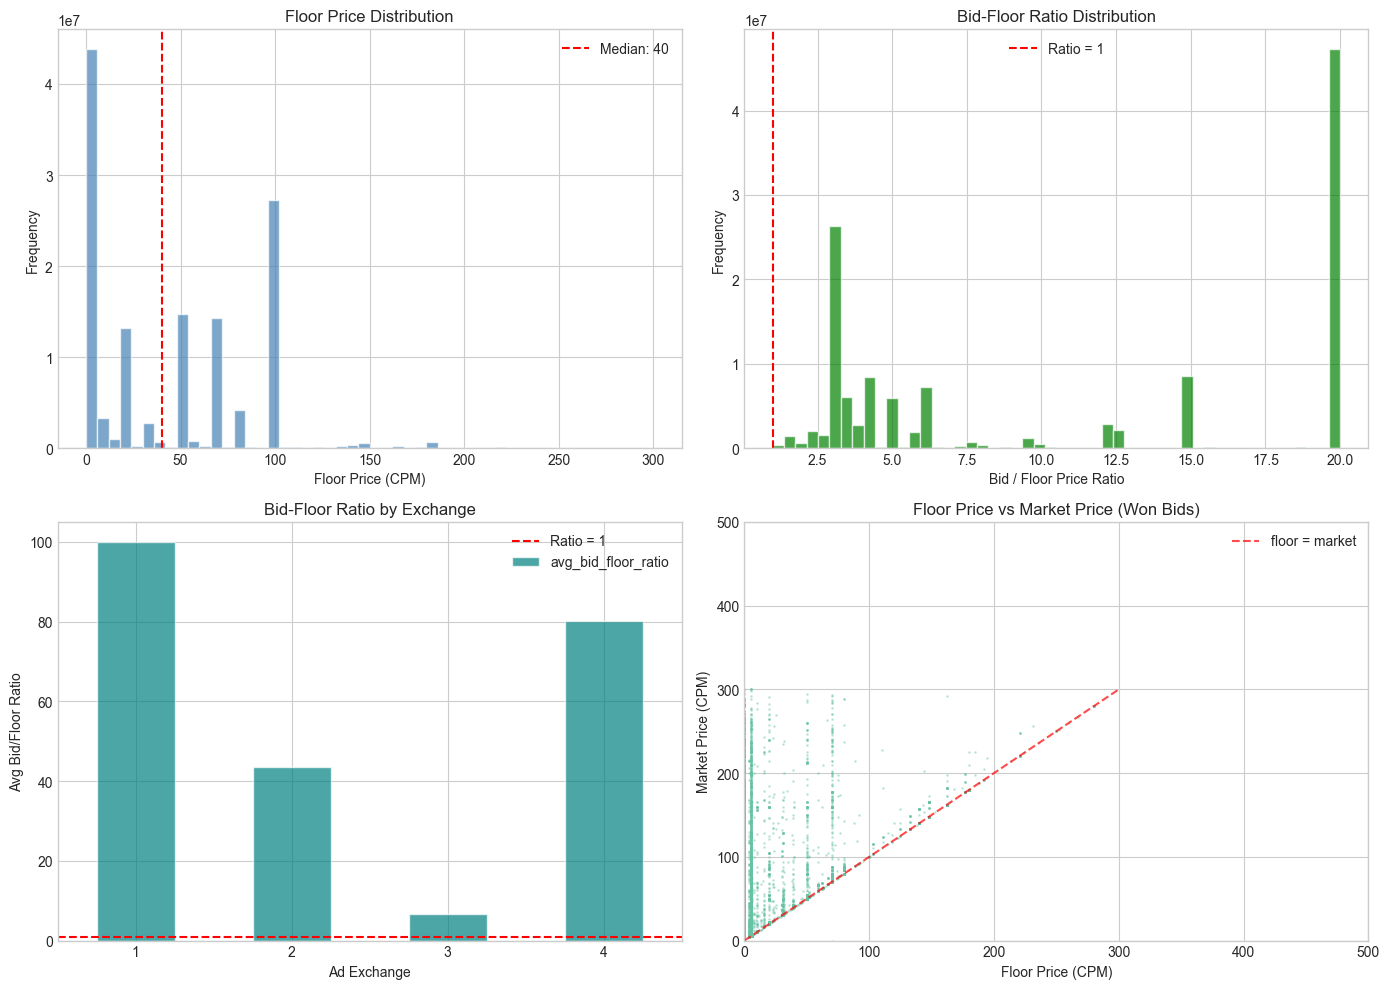

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Floor price distribution
ax = axes[0, 0]
floor_clipped = df['slotprice'].clip(0, 500)
ax.hist(floor_clipped, bins=50, alpha=0.7, color='steelblue', edgecolor='white')
ax.axvline(x=df['slotprice'].median(), color='red', linestyle='--',
           label=f'Median: {df["slotprice"].median():.0f}')
ax.set_xlabel('Floor Price (CPM)')
ax.set_ylabel('Frequency')
ax.set_title('Floor Price Distribution')
ax.legend()

# 2. Bid-floor ratio distribution
ax = axes[0, 1]
ratio_clipped = df['bid_floor_ratio'].clip(0, 20)
ax.hist(ratio_clipped, bins=50, alpha=0.7, color='green', edgecolor='white')
ax.axvline(x=1.0, color='red', linestyle='--', label='Ratio = 1')
ax.set_xlabel('Bid / Floor Price Ratio')
ax.set_ylabel('Frequency')
ax.set_title('Bid-Floor Ratio Distribution')
ax.legend()

# 3. Bid-floor ratio by exchange
ax = axes[1, 0]
floor_by_exchange['avg_bid_floor_ratio'].plot(kind='bar', ax=ax, color='teal', alpha=0.7)
ax.axhline(y=1.0, color='red', linestyle='--', label='Ratio = 1')
ax.set_xlabel('Ad Exchange')
ax.set_ylabel('Avg Bid/Floor Ratio')
ax.set_title('Bid-Floor Ratio by Exchange')
ax.legend()
ax.tick_params(axis='x', rotation=0)

# 4. Floor price vs market price (won bids)
ax = axes[1, 1]
sample_won = df_won.sample(min(10000, len(df_won)), random_state=42)
if 'slotprice' in sample_won.columns:
    ax.scatter(sample_won['slotprice'], sample_won['payprice'], alpha=0.3, s=1)
    max_val = max(sample_won['slotprice'].max(), sample_won['payprice'].max())
    ax.plot([0, min(max_val, 500)], [0, min(max_val, 500)], 'r--', alpha=0.7, label='floor = market')
    ax.set_xlim(0, 500)
    ax.set_ylim(0, 500)
    ax.set_xlabel('Floor Price (CPM)')
    ax.set_ylabel('Market Price (CPM)')
    ax.set_title('Floor Price vs Market Price (Won Bids)')
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_PATH / '01_eda_floor_price.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Floor Price — Interpretation

**Floor Price Distribution (좌상):**
- **Bimodal 분포**: 0~10 CPM (Exchange 1,2: floor 없거나 낮음) + 80~100 CPM (Exchange 3: 적극적 floor)
- Median 40 CPM이지만, 실제로는 "거의 없거나 / 높거나" 양극화
- 150 CPM 이상은 소수 premium inventory

**Bid-Floor Ratio Distribution (우상):**
- 대부분 ratio 2~5, ratio 20(clipped 상한)에 거대 spike → floor=0인 Exchange 1 bids
- 모든 ratio > 1 → bid coverage 100% (iPinYou bid는 항상 floor 초과)
- Shading 여지가 매우 넓음 — bid를 반으로 깎아도 대부분 floor 위

**Bid-Floor Ratio by Exchange (좌하):**

| Exchange | Avg Ratio | Floor (median) | 해석 |
|----------|-----------|----------------|------|
| 1 | 100 | 0 CPM | Floor 무의미, 순수 경쟁 |
| 2 | ~44 | 5 CPM | 명목상 floor, 실질 제약 약함 |
| 3 | ~6.6 | 70 CPM | **Floor가 실질적 제약** — shading 하한 |
| 4 | ~80 | 낮음 | Floor 무의미 |

**Floor vs Market Price 산점도 (우하):**
- 대부분의 점이 `floor = market` 대각선 위 → `payprice > slotprice` (경쟁이 floor 위에서 가격 결정)
- 대각선 근처의 점: floor binding (경쟁 약함, floor가 지불가 결정)
- floor=0 근처에서 market price 0~300 분포 → floor 없이도 경쟁만으로 가격 형성

**Bid shading 시사점:**
- Floor는 bid shading의 hard lower bound: `bid ≥ floor`
- Exchange 3만 floor가 실질적 제약으로 작동 (전체 볼륨의 60%)
- Exchange별 floor 구조가 다르므로 exchange-aware shading 필수

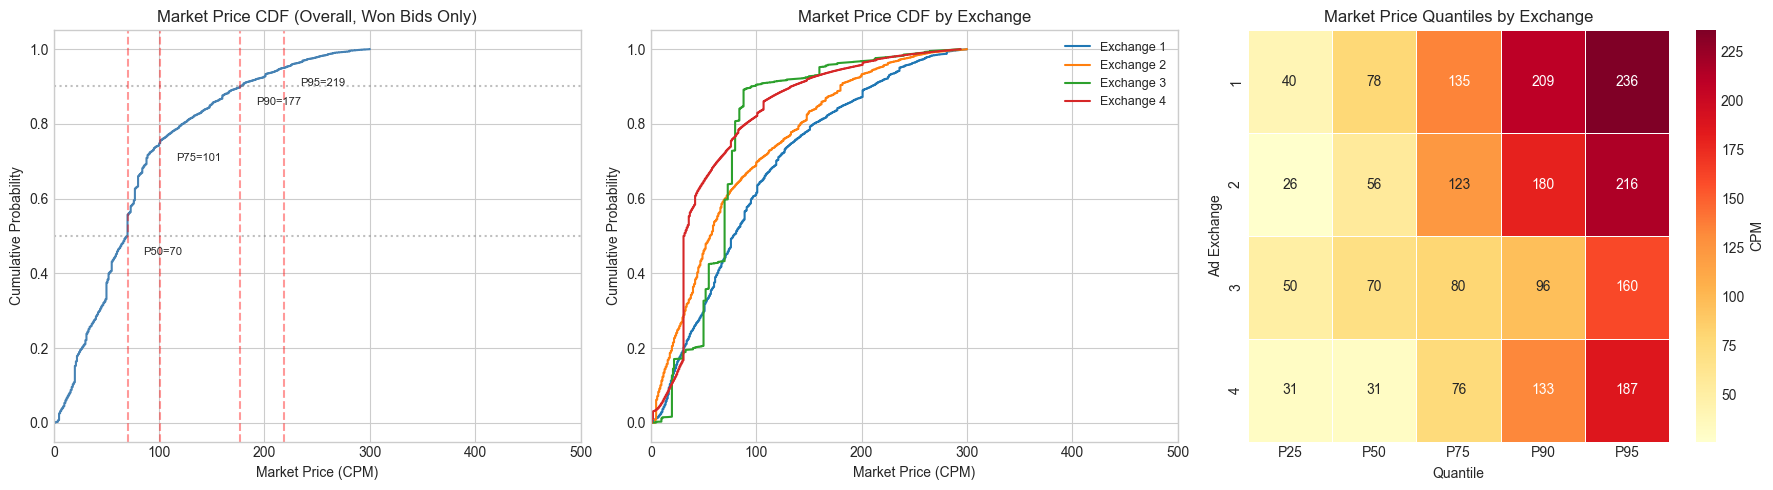

=== Market Price Quantiles by Exchange ===


,P25,P50,P75,P90,P95
adexchange,,,,,
1,40.0,78.0,135.0,209.0,236.0
2,26.0,56.0,123.0,180.0,216.0
3,50.0,70.0,80.0,96.0,160.0
4,31.0,31.0,76.0,133.0,187.0



Overall market price: median=70, mean=80, P90=177, P95=219 CPM


In [22]:
# 4.3 Market Price CDF by Exchange
# Empirical CDF of payprice (market clearing price) — direct input for bid shading
# Caveat: payprice is only observed for WON bids (right-censored at bidprice)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Overall market price empirical CDF
ax = axes[0]
payprice_sorted = np.sort(df_won['payprice'].dropna().values)
ecdf_y = np.arange(1, len(payprice_sorted) + 1) / len(payprice_sorted)
step = max(1, len(payprice_sorted) // 10000)
ax.plot(payprice_sorted[::step], ecdf_y[::step], '-', linewidth=1.5, color='steelblue')
ax.set_xlabel('Market Price (CPM)')
ax.set_ylabel('Cumulative Probability')
ax.set_title('Market Price CDF (Overall, Won Bids Only)')
ax.set_xlim(0, 500)
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
ax.axhline(y=0.9, color='gray', linestyle=':', alpha=0.5)
for q, label in [(0.5, 'P50'), (0.75, 'P75'), (0.9, 'P90'), (0.95, 'P95')]:
    val = np.quantile(payprice_sorted, q)
    ax.axvline(x=val, color='red', linestyle='--', alpha=0.4)
    ax.annotate(f'{label}={val:.0f}', xy=(val, q), fontsize=8,
                xytext=(val + 15, q - 0.05))

# 2. Exchange-level market price CDF
ax = axes[1]
exchange_colors = {1: 'tab:blue', 2: 'tab:orange', 3: 'tab:green', 4: 'tab:red'}
for exch_id in sorted(df_won['adexchange'].dropna().unique()):
    exch_prices = np.sort(df_won.loc[df_won['adexchange'] == exch_id, 'payprice'].dropna().values)
    if len(exch_prices) == 0:
        continue
    ecdf = np.arange(1, len(exch_prices) + 1) / len(exch_prices)
    step_e = max(1, len(exch_prices) // 5000)
    ax.plot(exch_prices[::step_e], ecdf[::step_e], '-', linewidth=1.5,
            label=f'Exchange {int(exch_id)}', color=exchange_colors.get(int(exch_id), 'gray'))
ax.set_xlabel('Market Price (CPM)')
ax.set_ylabel('Cumulative Probability')
ax.set_title('Market Price CDF by Exchange')
ax.set_xlim(0, 500)
ax.legend(fontsize=9)

# 3. Exchange-level quantile comparison heatmap
exchange_quantiles = (
    df_won.groupby('adexchange')['payprice']
    .quantile([0.25, 0.5, 0.75, 0.9, 0.95])
    .unstack(level=1)
)
exchange_quantiles.columns = ['P25', 'P50', 'P75', 'P90', 'P95']
exchange_quantiles = exchange_quantiles.astype(float)

ax = axes[2]
sns.heatmap(exchange_quantiles, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'CPM'})
ax.set_title('Market Price Quantiles by Exchange')
ax.set_xlabel('Quantile')
ax.set_ylabel('Ad Exchange')

plt.tight_layout()
plt.savefig(FIG_PATH / '01_eda_market_price_cdf.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Market Price Quantiles by Exchange ===")
display(exchange_quantiles.round(1))

print(f"\nOverall market price: median={df_won['payprice'].median():.0f}, "
      f"mean={df_won['payprice'].mean():.0f}, "
      f"P90={df_won['payprice'].quantile(0.9):.0f}, "
      f"P95={df_won['payprice'].quantile(0.95):.0f} CPM")

### 4.3 Market Price CDF — Interpretation

**Overall CDF (좌):**
- P50=70, P75=101, P90=177, P95=219 CPM
- iPinYou flat bid ~292 CPM은 P95(219)보다 높음 → 95% 이상의 경매에서 낙찰
- First-price 전환 시 동일 전략이면 매 경매마다 `bid - market_price` 만큼 과잉 지불

**Exchange별 CDF (중):**
- CDF 곡선이 Exchange마다 완전히 상이 → **단일 shading model 부적합**
- Exchange 1 (파랑): 가장 왼쪽 → 시장가 낮음 (floor=0, 저가 inventory)
- Exchange 3 (초록): 가장 오른쪽 → 시장가 높음 (floor=70, premium)
- 같은 100 CPM 입찰 시: Exchange 1에서 ~85% 낙찰 vs Exchange 3에서 ~35% 낙찰

**Exchange별 Quantile Heatmap (우):**

| Exchange | P25 | P50 | P75 | P90 | P95 | IQR | 특성 |
|----------|-----|-----|-----|-----|-----|-----|------|
| 1 | 40 | 78 | 135 | 209 | 236 | 95 | 넓은 분포, 높은 변동성 |
| 2 | 26 | 56 | 123 | 180 | 216 | 97 | 중간 |
| 3 | 50 | 70 | 80 | 96 | 160 | 30 | **좁은 분포**, floor(70) 주변 집중 |
| 4 | 31 | 31 | 76 | 133 | 187 | 45 | P25=P50 → 다수가 저가 낙찰 |

**Bid shading 직접 연결:**
- 이 CDF가 최적 입찰 공식의 핵심 입력: `max_b (V - b) × F(b)`
- Exchange 3: F가 가파름(좁은 분포) → bid 소폭 조정에도 win prob 급변 → floor 근처 공격적 shading 가능
- Exchange 1: F가 완만(넓은 분포) → bid를 많이 조정해야 win prob 유의미 변화 → 보수적 shading

**Censoring caveat:** 이 CDF는 **won bids only** 기반. Lost bids의 market price(> bidprice)는 관측 불가 → 실제 CDF의 right tail이 더 두꺼움. Win Tower(AUC ~0.91)가 이 censoring을 보정하여 full market price CDF를 추정하는 역할 (SP2).

In [23]:
# 4.4 Floor Price Binding Rate
# How often does the floor price actually determine the market clearing price?
# If payprice == slotprice, the floor is "binding" — no competitive pressure above floor

binding = df_won.assign(
    floor_binding=lambda x: (x['payprice'] == x['slotprice']).astype(int),
    floor_active=lambda x: (x['slotprice'] > 0).astype(int),
)

# Overall binding rate
overall_binding = binding['floor_binding'].mean()
active_floor_mask = binding['floor_active'] == 1
binding_among_active = binding.loc[active_floor_mask, 'floor_binding'].mean()

print("=== Floor Price Binding Rate ===")
print(f"Overall (all won bids):     {overall_binding:.2%}")
print(f"Among active floor (>0):    {binding_among_active:.2%}")
print(f"No floor (floor=0):         {(~active_floor_mask).mean():.2%} of won bids")

# Binding rate by exchange
binding_by_exchange = (
    binding.groupby('adexchange')
    .agg(
        n_won=('bidid', 'count'),
        n_binding=('floor_binding', 'sum'),
        n_active_floor=('floor_active', 'sum'),
        avg_floor=('slotprice', 'mean'),
        avg_market=('payprice', 'mean'),
    )
    .assign(
        binding_rate=lambda x: x['n_binding'] / x['n_won'],
        binding_rate_active=lambda x: x['n_binding'] / x['n_active_floor'].clip(lower=1),
        floor_market_gap=lambda x: x['avg_market'] - x['avg_floor'],
    )
)
print("\n=== Binding Rate by Exchange ===")
display(binding_by_exchange.round(4))

=== Floor Price Binding Rate ===
Overall (all won bids):     21.94%
Among active floor (>0):    32.24%
No floor (floor=0):         32.02% of won bids

=== Binding Rate by Exchange ===


,n_won,n_binding,n_active_floor,avg_floor,avg_market,binding_rate,binding_rate_active,floor_market_gap
adexchange,,,,,,,,
1,9221494,2,0,0.0,96.3116,0.0000,2.0000,96.3116
2,9565216,1575316,9565216,24.5835,78.8499,0.1647,0.1647,54.2664
3,10255296,4869560,10233860,53.0869,69.9675,0.4748,0.4758,16.8806
4,980564,0,409750,12.5362,59.5636,0.0000,0.0000,47.0274


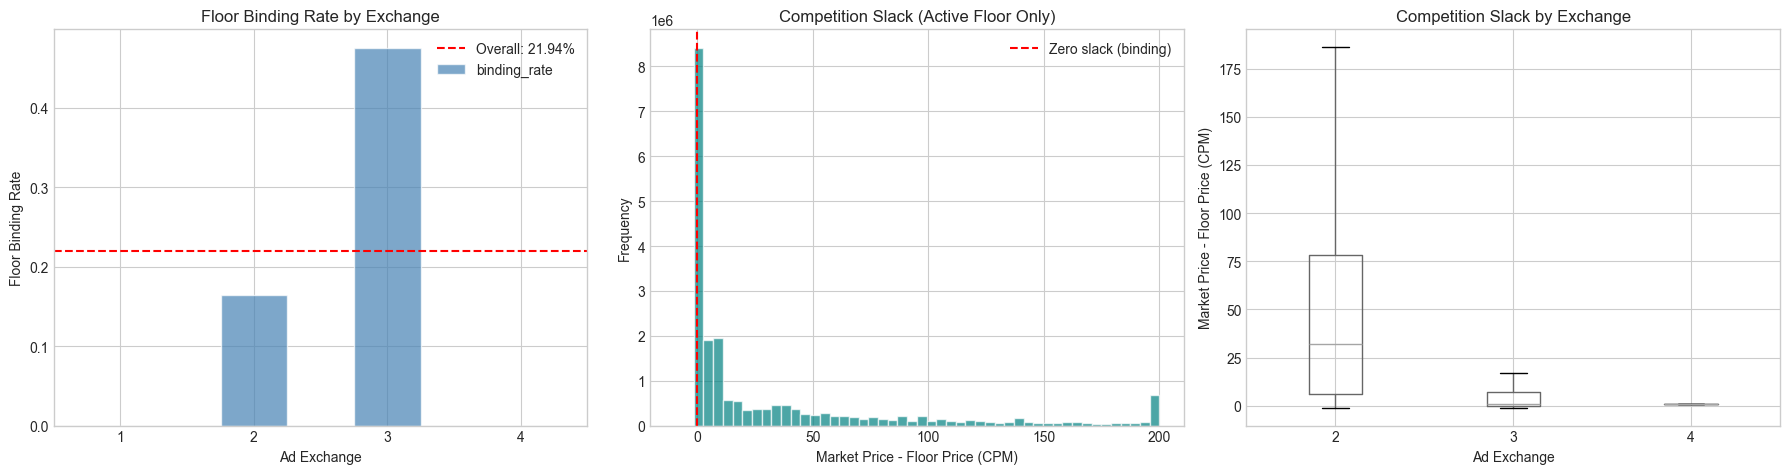


Implication for bid shading: When floor is binding (22% of won bids), bid shading should use floor price as the minimum bid, not shade below it.

=== Competition Intensity (market_price / floor_price, active floor only) ===
Median competition ratio: 1.10
Floor binding (ratio=1): 32.24%
Strong competition (ratio>2): 39.21%


In [24]:
# Competition slack: payprice - slotprice (won bids with active floor)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Binding rate by exchange
ax = axes[0]
binding_by_exchange['binding_rate'].plot(kind='bar', ax=ax, color='steelblue', alpha=0.7)
ax.set_xlabel('Ad Exchange')
ax.set_ylabel('Floor Binding Rate')
ax.set_title('Floor Binding Rate by Exchange')
ax.axhline(y=overall_binding, color='red', linestyle='--', label=f'Overall: {overall_binding:.2%}')
ax.legend()
ax.tick_params(axis='x', rotation=0)

# 2. Competition slack distribution (floor > 0)
ax = axes[1]
slack = binding.loc[active_floor_mask, 'payprice'] - binding.loc[active_floor_mask, 'slotprice']
slack_clipped = slack.clip(-10, 200)
ax.hist(slack_clipped, bins=50, alpha=0.7, color='teal', edgecolor='white')
ax.axvline(x=0, color='red', linestyle='--', label='Zero slack (binding)')
ax.set_xlabel('Market Price - Floor Price (CPM)')
ax.set_ylabel('Frequency')
ax.set_title('Competition Slack (Active Floor Only)')
ax.legend()

# 3. Competition slack by exchange (boxplot)
ax = axes[2]
slack_df = binding.loc[active_floor_mask].copy()
slack_df['slack'] = slack_df['payprice'] - slack_df['slotprice']
# Sample for boxplot efficiency
slack_sample = slack_df.sample(min(50000, len(slack_df)), random_state=42)
slack_sample.boxplot(column='slack', by='adexchange', ax=ax, showfliers=False)
ax.set_xlabel('Ad Exchange')
ax.set_ylabel('Market Price - Floor Price (CPM)')
ax.set_title('Competition Slack by Exchange')
plt.suptitle('')  # Remove auto-title from boxplot

plt.tight_layout()
plt.savefig(FIG_PATH / '01_eda_floor_binding.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nImplication for bid shading: When floor is binding ({overall_binding:.0%} of won bids), "
      f"bid shading should use floor price as the minimum bid, not shade below it.")

# Competition intensity (merged from former Section 12.6)
df_won_floor_comp = df_won[df_won['slotprice'] > 0].copy()
df_won_floor_comp['competition_ratio'] = df_won_floor_comp['payprice'] / df_won_floor_comp['slotprice']
print(f"\n=== Competition Intensity (market_price / floor_price, active floor only) ===")
print(f"Median competition ratio: {df_won_floor_comp['competition_ratio'].median():.2f}")
print(f"Floor binding (ratio=1): {(df_won_floor_comp['competition_ratio'] == 1).mean():.2%}")
print(f"Strong competition (ratio>2): {(df_won_floor_comp['competition_ratio'] > 2).mean():.2%}")

### 4.4 Floor Binding & Competition Intensity — Interpretation

**Floor Binding:**
- When floor is binding (payprice == slotprice), competition is weak — the floor determines price
- In these cases, bid shading below floor is pointless; the floor is the effective minimum
- Exchange 3 with active floors will have high binding rates
- Exchange 1 (no floor) will have 0% binding — market price is purely competition-driven

**Competition Intensity (market_price / floor_price):**
- Median ratio ~1.10 → 대부분의 won bids에서 market price가 floor 대비 10% 내외 높음
- Binding ~32% → 약 1/3의 낙찰에서 floor = market price (경쟁 부재)
- Strong competition (ratio > 2) ~39% → 나머지 약 2/5에서는 floor 대비 2배 이상 경쟁
- **양극화된 경쟁 구조**: floor binding vs strong competition, 중간이 적음

**Bid Optimization 시사점:**
- Bid shading lower bound: `bid ≥ max(floor_price, shade(x))` — floor 아래 입찰은 낙찰 불가
- Floor binding이 높은 exchange/시간대에서는 shade가 floor에 수렴 → 절감 여지 작음
- Strong competition 구간에서 shade(x) 최적화의 실질적 가치 집중

## 5. Feature-level EDA

Analyze click rates and feature distributions.

### 5.1 CTR Distribution

In [25]:
# CTR by hour (won impressions only)
hourly_ctr = (
    df_won.groupby('hour')
    .agg(
        n_impressions=('bidid', 'count'),
        n_clicks=('click', 'sum'),
    )
    .assign(ctr=lambda x: x['n_clicks'] / x['n_impressions'])
)

print("CTR by Hour:")
display(hourly_ctr)

CTR by Hour:


,n_impressions,n_clicks,ctr
hour,,,
0,2286748,1732,0.000757
1,755396,472,0.000625
2,433706,242,0.000558
3,417712,240,0.000575
4,234660,132,0.000563
5,247174,182,0.000736
6,288930,168,0.000581
7,583210,416,0.000713
8,866118,498,0.000575


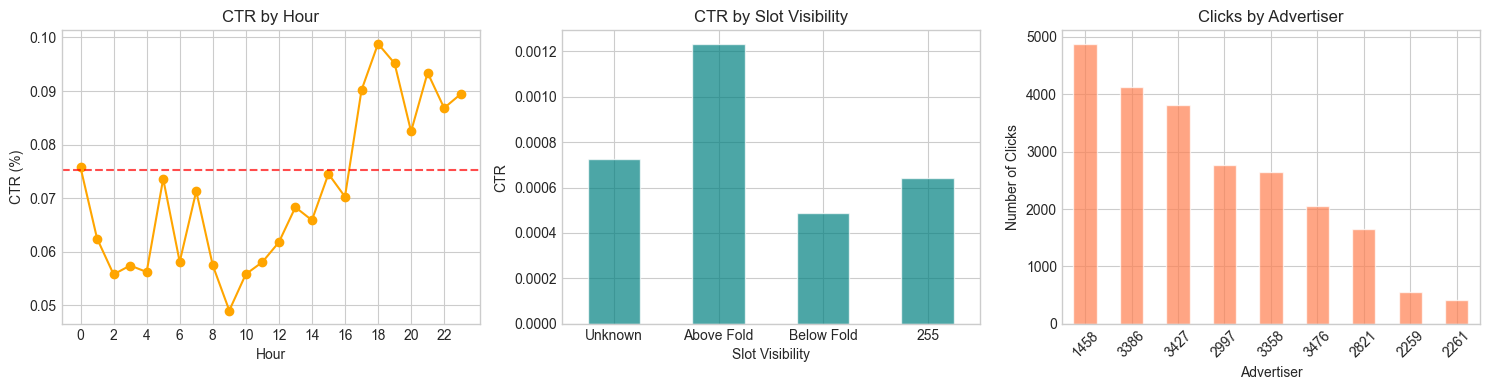

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. CTR by hour
ax = axes[0]
ax.plot(hourly_ctr.index, hourly_ctr['ctr'] * 100, 'o-', color='orange')
ax.axhline(y=stats_overall.ctr * 100, color='red', linestyle='--', alpha=0.7)
ax.set_xlabel('Hour')
ax.set_ylabel('CTR (%)')
ax.set_title('CTR by Hour')
ax.set_xticks(range(0, 24, 2))

# 2. CTR by slot visibility
ax = axes[1]
if 'slotvisibility' in df_won.columns:
    vis_ctr = (
        df_won.groupby('slotvisibility')
        .agg(n=('bidid', 'count'), clicks=('click', 'sum'))
        .assign(ctr=lambda x: x['clicks'] / x['n'])
    )
    vis_labels = {0: 'Unknown', 1: 'Above Fold', 2: 'Below Fold'}
    vis_ctr.index = vis_ctr.index.map(lambda x: vis_labels.get(x, str(x)))
    vis_ctr['ctr'].plot(kind='bar', ax=ax, color='teal', alpha=0.7)
    ax.set_xlabel('Slot Visibility')
    ax.set_ylabel('CTR')
    ax.set_title('CTR by Slot Visibility')
    ax.tick_params(axis='x', rotation=0)

# 3. Click distribution by advertiser
ax = axes[2]
click_dist = df_won.groupby('advertiser')['click'].sum().sort_values(ascending=False)
click_dist.plot(kind='bar', ax=ax, color='coral', alpha=0.7)
ax.set_xlabel('Advertiser')
ax.set_ylabel('Number of Clicks')
ax.set_title('Clicks by Advertiser')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIG_PATH / '01_eda_ctr_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.1 CTR Distribution — Interpretation

**CTR ~0.075%는 display ad 업계 평균(0.05~0.1%) 범위 내** → 정상적인 display inventory 확인.

**Viewability (Above Fold) 효과:**
- Above Fold > Below Fold CTR → 광고 가치 V(x) 계산 시 `slotvisibility` 반드시 포함
- Unknown visibility가 대다수인 경우 → visibility 변수의 실질적 coverage 확인 필요

**CTR 시간대 패턴 vs Win Rate 패턴:**
- Win rate가 높은 야간 시간대에 CTR이 낮다면 → 경쟁은 낮지만 유저 engagement도 낮음
- 이 경우 bid value `V(x) = pCTR × value_per_click`에서 시간 component가 win rate와 반대 방향으로 작용
- **Bid = V(x) × shade(x)** 에서 V(x)와 shade(x) 모두에 hour가 영향 → 최적 bid의 시간대 패턴은 단순하지 않음

**Advertiser별 Click 분포 (우):**
- Click 수가 소수 advertiser에 극도로 집중 → Pareto 패턴
- Click이 많은 advertiser = bid volume 多 × CTR 상대적 高 → 모델 학습 시 이 advertiser의 가중치가 큼
- Click 희소 advertiser는 CTR 추정 불안정 → advertiser-level smoothing 또는 hierarchical prior 필요

**Feature Engineering 시사점:**
- `hour`, `slotvisibility`, `advertiser` 모두 CTR에 영향 → ESMM-WC / ESCM²-WC 입력 feature
- 특히 `hour`는 win rate(Section 3)와 CTR 양쪽에 영향 → bid value와 win probability 모두의 driver

### 5.2 Ad Format & Slot Analysis

Analyze win rate and CTR by ad format (slotformat).

In [27]:
# Slot size distribution
if 'slotwidth' in df.columns and 'slotheight' in df.columns:
    if 'slot_size' not in df.columns:
        df['slot_size'] = df['slotwidth'].astype(str) + 'x' + df['slotheight'].astype(str)
    
    slot_stats = (
        df.groupby('slot_size')
        .agg(
            n_bids=('bidid', 'count'),
            n_wins=('win', 'sum'),
            n_clicks=('click', 'sum'),
        )
        .assign(
            win_rate=lambda x: x['n_wins'] / x['n_bids'],
            ctr=lambda x: x['n_clicks'] / x['n_wins'].replace(0, 1),
        )
        .sort_values('n_bids', ascending=False)
    )
    
    print("Top 10 Slot Sizes:")
    display(slot_stats.head(10).round(4))

Top 10 Slot Sizes:


,n_bids,n_wins,n_clicks,win_rate,ctr
slot_size,,,,,
300x250,53908950,7943836,6788,0.1474,0.0009
1000x90,30543898,6918240,5428,0.2265,0.0008
728x90,12625382,4664078,2698,0.3694,0.0006
960x90,7528154,1252464,688,0.1664,0.0005
336x280,5790692,2923516,1646,0.5049,0.0006
250x250,4203690,1416518,452,0.3370,0.0003
160x600,3134006,1481712,998,0.4728,0.0007
468x60,2919118,597968,338,0.2048,0.0006
950x90,2380382,1360516,846,0.5716,0.0006


In [28]:
# Ad format distribution
format_labels = {0: 'Unknown', 1: 'Fixed Banner', 2: 'Fixed Banner (2)', 5: 'Pop-up'}

format_stats = (
    df.groupby('slotformat')
    .agg(
        n_bids=('bidid', 'count'),
        n_wins=('win', 'sum'),
        n_clicks=('click', 'sum'),
    )
    .assign(
        win_rate=lambda x: x['n_wins'] / x['n_bids'],
        ctr=lambda x: x['n_clicks'] / x['n_wins'].clip(lower=1),
        pct=lambda x: x['n_bids'] / x['n_bids'].sum() * 100,
    )
    .sort_values('n_bids', ascending=False)
)

print("Ad Format Statistics:")
display(format_stats.round(4))

Ad Format Statistics:


,n_bids,n_wins,n_clicks,win_rate,ctr,pct
slotformat,,,,,,
0,94344000,16697052,10726,0.1770,0.0006,88.5205
1,11783944,7520226,5550,0.6382,0.0007,11.0566
5,450716,163416,1400,0.3626,0.0086,0.4229


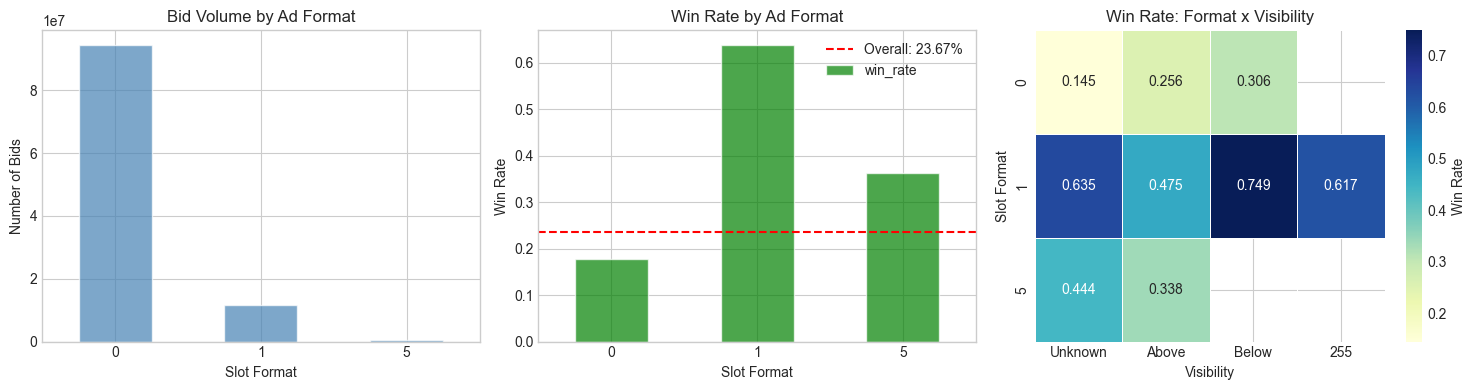

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Volume by format
ax = axes[0]
format_stats['n_bids'].plot(kind='bar', ax=ax, color='steelblue', alpha=0.7)
ax.set_xlabel('Slot Format')
ax.set_ylabel('Number of Bids')
ax.set_title('Bid Volume by Ad Format')
ax.tick_params(axis='x', rotation=0)

# 2. Win rate by format
ax = axes[1]
format_stats['win_rate'].plot(kind='bar', ax=ax, color='green', alpha=0.7)
ax.axhline(y=stats_overall.win_rate, color='red', linestyle='--', label=f'Overall: {stats_overall.win_rate:.2%}')
ax.set_xlabel('Slot Format')
ax.set_ylabel('Win Rate')
ax.set_title('Win Rate by Ad Format')
ax.legend()
ax.tick_params(axis='x', rotation=0)

# 3. Format x Visibility heatmap
ax = axes[2]
if 'slotvisibility' in df.columns:
    fmt_vis = (
        df.groupby(['slotformat', 'slotvisibility'])
        .agg(n_wins=('win', 'sum'), n_bids=('bidid', 'count'))
        .assign(win_rate=lambda x: x['n_wins'] / x['n_bids'])
        ['win_rate']
        .unstack('slotvisibility')
    )
    vis_labels = {k: v.split()[0] if ' ' in v else v for k, v in VIS_LABELS.items()}
    fmt_vis = fmt_vis.rename(columns=vis_labels)
    sns.heatmap(fmt_vis, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'Win Rate'})
    ax.set_title('Win Rate: Format x Visibility')
    ax.set_xlabel('Visibility')
    ax.set_ylabel('Slot Format')

plt.tight_layout()
plt.savefig(FIG_PATH / '01_eda_ad_format.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Ad Format — Interpretation

**Bid Volume by Format (좌):**
- Fixed Banner (format 1)이 전체 bid의 대다수 차지 → 표준 display inventory 중심
- Pop-up (format 5)은 소량이지만 CTR 이상치로 주의 필요

**Win Rate by Format (중):**
- Format 간 win rate 차이 존재 — 경쟁 강도가 format에 따라 다름
- Pop-up은 경쟁 낮음 (공급 자체가 적음) → 높은 win rate

**Format × Visibility Heatmap (우):**
- Fixed Banner + Above Fold가 가장 가치 높은 조합 (높은 viewability + 정상적 CTR)
- Below Fold가 Above Fold보다 높은 win rate/CTR을 보이면 → bot traffic 또는 데이터 품질 이슈 의심
- Unknown visibility가 다수인 format은 visibility feature의 실효성 제한

**Pop-up (format 5) CTR 0.86% = 11.4× 평균 → IVT/misclick 신호:**
- RTB 업계에서 pop-up의 높은 CTR은 대부분 실수 클릭이나 forced exposure (강제 노출)
- CTR 모델 학습 시 format 5를 별도 처리하거나 제외 권장 — misclick을 genuine interest로 학습하면 모델 편향

**Slot Size 통계 (code cell 출력):**
- IAB 표준 크기별 volume/win rate/CTR 상이
- 300x250 (Medium Rectangle), 728x90 (Leaderboard) 등 인기 크기가 대부분
- 크기별 win rate 변동 → `slot_size`를 win tower feature로 포함 (Section 3에서도 확인)

**모델링 시사점:**
- `slotformat`을 ESMM-WC / ESCM²-WC CTR 모델의 feature로 포함하되, pop-up은 별도 indicator 또는 학습 데이터에서 제외
- Bid value 계산: `V(x) = debiased_pCTR(format, visibility, ...) × CPC_target` — format이 V(x)에 직접 영향

### 5.3 Geographic Concentration

Analyze bid volume, win rate, and CTR by geographic region.

In [30]:
# Region stats
region_stats = (
    df.groupby('region')
    .agg(
        n_bids=('bidid', 'count'),
        n_wins=('win', 'sum'),
        n_clicks=('click', 'sum'),
    )
    .assign(
        win_rate=lambda x: x['n_wins'] / x['n_bids'],
        ctr=lambda x: x['n_clicks'] / x['n_wins'].clip(lower=1),
    )
    .sort_values('n_bids', ascending=False)
)

print(f"Total unique regions: {df['region'].nunique()}")
print(f"Total unique cities: {df['city'].nunique()}")

# Pareto analysis: top N regions → X% of bids
cumulative = region_stats['n_bids'].cumsum() / region_stats['n_bids'].sum()
n_80 = (cumulative <= 0.8).sum() + 1
print(f"\nRegion concentration: Top {n_80} regions ({n_80/len(region_stats)*100:.1f}%) account for 80% of bids")
print(f"Win rate range: {region_stats['win_rate'].min():.2%} ~ {region_stats['win_rate'].max():.2%}")
print(f"CTR range: {region_stats['ctr'].min():.4%} ~ {region_stats['ctr'].max():.4%}")

Total unique regions: 36
Total unique cities: 371

Region concentration: Top 17 regions (47.2%) account for 80% of bids
Win rate range: 11.31% ~ 56.78%
CTR range: 0.0000% ~ 0.1297%


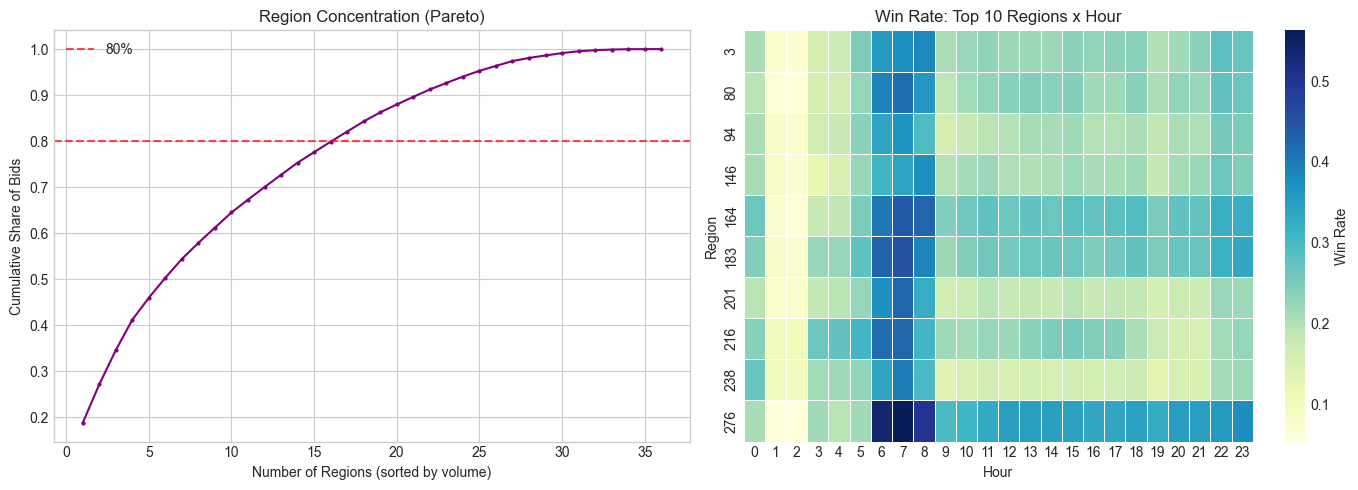

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Region concentration (Pareto)
ax = axes[0]
cumulative = region_stats['n_bids'].cumsum() / region_stats['n_bids'].sum()
ax.plot(range(1, len(cumulative) + 1), cumulative.values, 'o-', markersize=2, color='purple')
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.7, label='80%')
ax.set_xlabel('Number of Regions (sorted by volume)')
ax.set_ylabel('Cumulative Share of Bids')
ax.set_title('Region Concentration (Pareto)')
ax.legend()

# 2. Region x Hour win rate heatmap (top 10 regions)
ax = axes[1]
if 'hour' in df.columns:
    top10_regions = region_stats.head(10).index.tolist()
    region_hour_wr = (
        df[df['region'].isin(top10_regions)]
        .groupby(['region', 'hour'])
        .agg(n_bids=('bidid', 'count'), n_wins=('win', 'sum'))
        .assign(win_rate=lambda x: x['n_wins'] / x['n_bids'])
        ['win_rate']
        .unstack('hour')
    )
    sns.heatmap(region_hour_wr, cmap='YlGnBu', ax=ax, linewidths=0.5,
                cbar_kws={'label': 'Win Rate'})
    ax.set_title('Win Rate: Top 10 Regions x Hour')
    ax.set_xlabel('Hour')
    ax.set_ylabel('Region')

plt.tight_layout()
plt.savefig(FIG_PATH / '01_eda_geographic.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Geographic — Interpretation

**Region Concentration — Pareto (좌):**
- Top 17 / 36 regions = 80% of bids → 극단적 지리적 집중
- Long-tail: 하위 19개 region은 전체 bid의 20% → 개별 region-level 통계 불안정
- Region별 win rate/CTR 변동 → region을 feature로 포함 시 bid value 차별화 가능

**Region × Hour Win Rate Heatmap (우):**
- Top 10 regions의 시간대별 win rate 패턴이 시각화됨
- 동일 hour에서도 region 간 win rate 차이 → 지역별 경쟁 강도 상이
- 동일 region에서도 hour별 win rate 변동 → 시간대별 경쟁 패턴이 지역마다 다름
- 특정 region-hour 조합에서 win rate 극단값 (매우 높거나 낮음) → bid 조정 기회
- **Section 3의 Hour × Advertiser heatmap과 함께** → hour, region, advertiser 3차원 교차가 win rate를 결정

**Feature Engineering 시사점:**
- `region`을 Win Tower 및 CTR Tower feature로 포함
- Region × hour interaction은 bid shading factor 후보 — 단, high-cardinality로 embedding 또는 target encoding 필요
- Long-tail region은 grouping (e.g., province 단위) 또는 smoothing 적용

### 5.4 Publisher Concentration

Analyze bid volume concentration and CPM variance across publisher domains.

In [32]:
# Domain stats
domain_stats = (
    df.groupby('domain')
    .agg(
        n_bids=('bidid', 'count'),
        n_wins=('win', 'sum'),
        n_clicks=('click', 'sum'),
    )
    .assign(
        win_rate=lambda x: x['n_wins'] / x['n_bids'],
        ctr=lambda x: x['n_clicks'] / x['n_wins'].clip(lower=1),
    )
    .sort_values('n_bids', ascending=False)
)

print(f"Total unique domains: {df['domain'].nunique()}")

# Domain concentration
cumulative_d = domain_stats['n_bids'].cumsum() / domain_stats['n_bids'].sum()
n_80_d = (cumulative_d <= 0.8).sum() + 1
print(f"Domain concentration: Top {n_80_d} domains ({n_80_d/len(domain_stats)*100:.1f}%) account for 80% of bids")

# Top 10 domains
print("\nTop 10 Domains by Volume:")
display(domain_stats.head(10).round(4))

Total unique domains: 108081
Domain concentration: Top 238 domains (0.2%) account for 80% of bids

Top 10 Domains by Volume:


,n_bids,n_wins,n_clicks,win_rate,ctr
domain,,,,,
5F1RQS9rg5scFsf,9926460,2415978,2078,0.2434,0.0009
31xSTvprdN1RFt,6961244,1720108,304,0.2471,0.0002
tMxYQ19aM98,6079732,0,0,0.0000,0.0000
ersbQv1RdoTy1m58uG,6024874,1014108,922,0.1683,0.0009
3FKElpuEMusyJqKbuKz,3578292,796076,728,0.2225,0.0009
3FF-e59aG5syJqKbuKz,2741764,559578,724,0.2041,0.0013
trqRTuMvjTN7X9KbuKz,2495746,938808,508,0.3762,0.0005
DDTSQuf0MTTNaqKIvMpENpn,2285500,345506,162,0.1512,0.0005
DD1SqS9rg5scFsf,1968022,353574,306,0.1797,0.0009


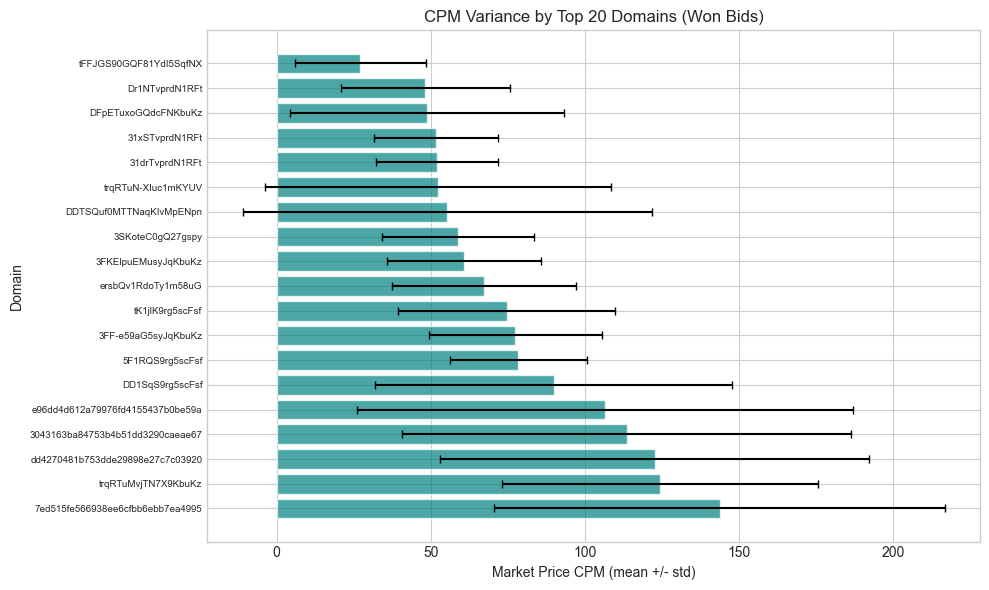

In [33]:
# CPM variance by top 20 domains (won bids only)
fig, ax = plt.subplots(figsize=(10, 6))

if 'domain' in df_won.columns:
    top20_domains = domain_stats.head(20).index.tolist()
    domain_cpm = (
        df_won[df_won['domain'].isin(top20_domains)]
        .groupby('domain')['payprice']
        .agg(['mean', 'std'])
        .sort_values('mean', ascending=False)
    )
    ax.barh(range(len(domain_cpm)), domain_cpm['mean'], xerr=domain_cpm['std'],
            color='teal', alpha=0.7, capsize=3)
    ax.set_yticks(range(len(domain_cpm)))
    ax.set_yticklabels(domain_cpm.index, fontsize=7)
    ax.set_xlabel('Market Price CPM (mean +/- std)')
    ax.set_ylabel('Domain')
    ax.set_title('CPM Variance by Top 20 Domains (Won Bids)')

plt.tight_layout()
plt.savefig(FIG_PATH / '01_eda_publisher.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Publisher — Interpretation

**Domain Concentration:**
- 238 / 108K domains = 80% of bids → 극소수 도메인에 극단적 집중 (상위 0.2%)
- High-volume 도메인은 충분한 샘플로 domain-level 통계 안정적 활용 가능
- Long-tail 도메인(108K 중 대부분)은 개별 추정 불가 → smoothing 또는 domain grouping 필수

**CPM Variance by Top 20 Domains (plot):**
- 도메인별 mean CPM이 크게 상이 → 동일 bid로 모든 도메인에 입찰하는 것은 비효율적
- Error bar(std)가 큰 도메인: 동일 도메인 내에서도 시간대/유저/경쟁에 따라 market price 변동 큼 → domain만으로는 가격 예측 불충분
- Error bar가 작은 도메인: 안정적 가격 → domain-level bid shading이 효과적
- Mean CPM이 높은 도메인 = premium inventory → floor binding이 높을 가능성, Exchange 3과 연관 가능

**Bid Shading 시사점:**
- Domain은 market price의 핵심 결정 변수 → Win Tower feature로 포함
- 단, 108K cardinality → 직접 one-hot 불가, hashing 또는 frequency-based encoding 필요
- Domain × exchange 교차 분석이 유의미할 수 있음 (특정 도메인이 특정 exchange에 집중)

## 6. Usertag Analysis

Analyze user profile tags: distribution, advertiser targeting patterns, relationship with Win/CTR/CVR, and tag co-occurrence.

*Note: Usertag parsing 코드는 65M rows 대상 heavy computation으로 제거. 아래는 분석 결과 요약.*

### Usertag Analysis Summary

**Critical Finding: Label Leakage**

`has_tags=1` → Win Rate = 100%. Usertag is populated **only for won impressions** (via impression logs). This means:

| Model | Usertag Allowed? | Reason |
|-------|-----------------|--------|
| Win Prediction / ESMM-WC / ESCM²-WC Win Tower | **No** | `has_tags` perfectly predicts win (leakage) |
| CTR Model (ESCM²-WC CTR Tower, won-only) | Possible | But only on won impressions; limited incremental value |

**Other Findings:**
- Vocabulary = 68 unique tags (coarse categories, not fine-grained interests)
- 81% of bid requests lack usertags; among rows with tags, mean = 5.66 tags/row
- `n_tags=0` showing highest CTR among won impressions reflects **inventory quality confounding**, not user quality

**Decision**: This project does **not** use usertag as a model feature. Summary features (`n_tags`, `has_tags`) are retained in the feature set for documentation purposes only.

## 7. Data Quality & Anomaly Detection

Identify data quality issues, suspicious traffic patterns, and advertiser-exchange interactions.

=== IVT Signal 1: 0% Win Rate Domains (volume >= 1000) ===
Count: 76 domains, 7,163,984 total bids


,n_bids,n_wins,n_clicks,win_rate,ctr
domain,,,,,
tMxYQ19aM98,6079732,0,0,0.0,0.0
5D1El5C0gQ27gspy,291076,0,0,0.0,0.0
eSxETvpWM9so1YdI5SqfNX,228430,0,0,0.0,0.0
tMxXe5sUGqsb1m58uG,221166,0,0,0.0,0.0
erdgQF9xG927Jd9h5SqW,95200,0,0,0.0,0.0
D1TSZS9cQq9oJ9KIvMpENpn,19142,0,0,0.0,0.0
ad577d540bc0a709cdfbad618e25e2df,15794,0,0,0.0,0.0
3KKSe19JXQ5R1YdI5SqfNX,9368,0,0,0.0,0.0
trqRTumJMNuvjdC4JKTI,9328,0,0,0.0,0.0



=== IVT Signal 2: >90% Win Rate Domains ===
Count: 2 domains, 5,256 total bids


,n_bids,n_wins,n_clicks,win_rate,ctr
domain,,,,,
215ee90878d107630652d5c8f7ab7c0a,4254,3888,0,0.913963,0.0
3e2ea59437f775b6b64a3a8385e3f8eb,1002,926,0,0.924152,0.0



=== IVT Signal 3: High-Volume Won + 0 Clicks (>= 1000 impressions) ===
Count: 741 domains, 2,885,456 total impressions with zero clicks


,n_bids,n_wins,n_clicks,win_rate,ctr
domain,,,,,
3SCYZrn0Qo18XMB4JKTI,478492,257212,0,0.537547,0.0
da19f9802cd78a3c0f472c464c05013f,145158,28810,0,0.198473,0.0
369fbd5dd0636d8b3e8199bf027854b1,142192,79734,0,0.560749,0.0
b5f57062ae7f4ba7f1489b9133b991d6,109774,29390,0,0.267732,0.0
eKFjTu1Jgqc7gspy,106212,85214,0,0.802301,0.0
trqRTJlIjoj7gspy,82156,20742,0,0.252471,0.0
a0d5ca0e94412540dd31acbd5b991fb3,78596,51008,0,0.648990,0.0
5FpgTuFygZl7gspy,71606,26914,0,0.375862,0.0
3K1oqrl4dN17gMNWcdpENpn,67622,36528,0,0.540179,0.0


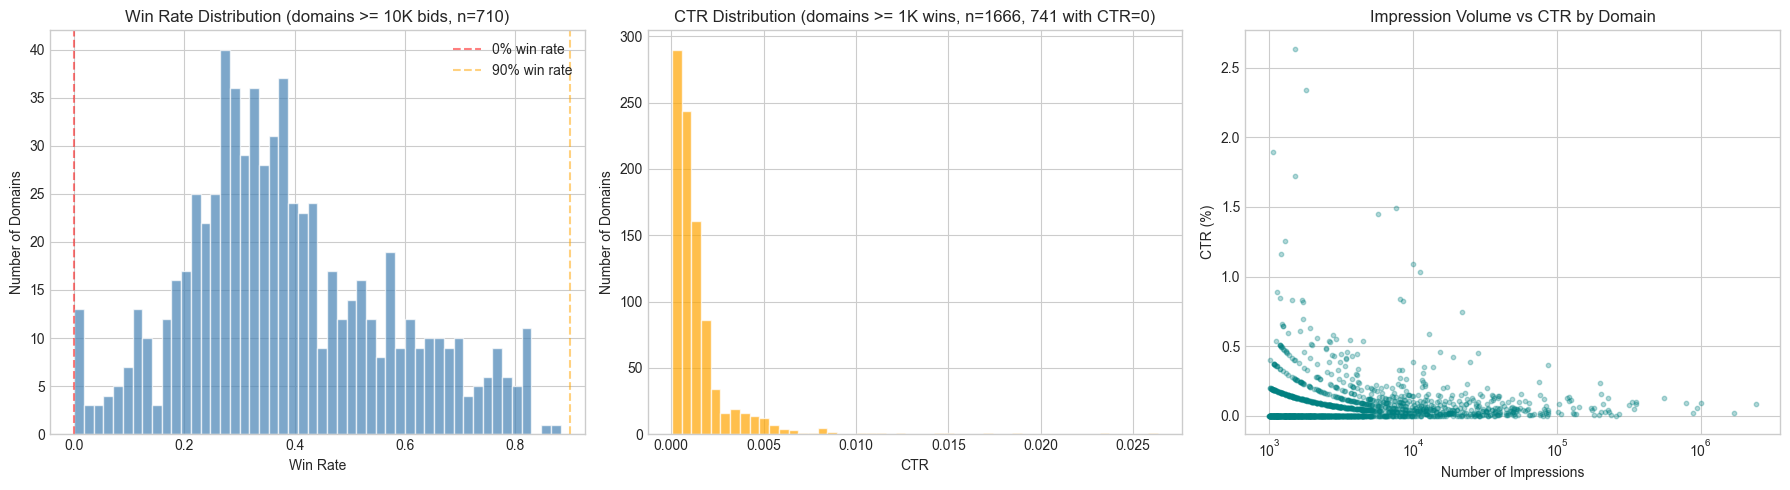


=== IVT Screening Summary ===
Domains analyzed (>= 1000 bids): 3,362
  0% win rate:         76 (2.3%)
  >90% win rate:        2 (0.1%)
  High-vol no-click:  741 (22.0%)


In [34]:
# 7.1 IVT/Fraud Signal Screening
# Identify domains with suspicious patterns that may indicate invalid traffic

# Reuse domain_stats from Section 5.4 (avoids duplicate groupby)
MIN_BIDS = 1000

domain_quality = domain_stats.query(f'n_bids >= {MIN_BIDS}').copy()

# Flag 1: High-volume domains with 0% win rate (data issue or extreme competition)
zero_win = domain_quality.query('win_rate == 0')
print(f"=== IVT Signal 1: 0% Win Rate Domains (volume >= {MIN_BIDS}) ===")
print(f"Count: {len(zero_win)} domains, {zero_win['n_bids'].sum():,} total bids")
if len(zero_win) > 0:
    display(zero_win.head(10))

# Flag 2: Extreme win rate domains (>90%) — low competition, potentially low quality
extreme_win = domain_quality.query('win_rate > 0.90')
print(f"\n=== IVT Signal 2: >90% Win Rate Domains ===")
print(f"Count: {len(extreme_win)} domains, {extreme_win['n_bids'].sum():,} total bids")
if len(extreme_win) > 0:
    display(extreme_win.head(10))

# Flag 3: High-volume won domains with 0 clicks (potential bot traffic)
high_vol_no_click = domain_quality.query('n_wins >= 1000 and n_clicks == 0')
print(f"\n=== IVT Signal 3: High-Volume Won + 0 Clicks (>= 1000 impressions) ===")
print(f"Count: {len(high_vol_no_click)} domains, "
      f"{high_vol_no_click['n_wins'].sum():,} total impressions with zero clicks")
if len(high_vol_no_click) > 0:
    display(high_vol_no_click.head(10))

# Flag 4: Bimodal CTR distribution check
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Win rate distribution of high-volume domains
ax = axes[0]
high_vol = domain_quality.query('n_bids >= 10000')
ax.hist(high_vol['win_rate'], bins=50, alpha=0.7, color='steelblue', edgecolor='white')
ax.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='0% win rate')
ax.axvline(x=0.9, color='orange', linestyle='--', alpha=0.5, label='90% win rate')
ax.set_xlabel('Win Rate')
ax.set_ylabel('Number of Domains')
ax.set_title(f'Win Rate Distribution (domains >= 10K bids, n={len(high_vol)})')
ax.legend()

# 2. CTR distribution of high-volume won domains
ax = axes[1]
high_vol_won = domain_quality.query('n_wins >= 1000')
ctr_vals = high_vol_won['ctr']
ax.hist(ctr_vals[ctr_vals > 0], bins=50, alpha=0.7, color='orange', edgecolor='white')
n_zero_ctr = (ctr_vals == 0).sum()
ax.set_xlabel('CTR')
ax.set_ylabel('Number of Domains')
ax.set_title(f'CTR Distribution (domains >= 1K wins, n={len(high_vol_won)}, '
             f'{n_zero_ctr} with CTR=0)')

# 3. Scatter: Volume vs CTR (anomaly detection)
ax = axes[2]
ax.scatter(high_vol_won['n_wins'], high_vol_won['ctr'] * 100,
           s=10, alpha=0.3, color='teal')
ax.set_xlabel('Number of Impressions')
ax.set_ylabel('CTR (%)')
ax.set_title('Impression Volume vs CTR by Domain')
ax.set_xscale('log')

plt.tight_layout()
plt.savefig(FIG_PATH / '01_eda_ivt_screening.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print(f"\n=== IVT Screening Summary ===")
total_domains = len(domain_quality)
print(f"Domains analyzed (>= {MIN_BIDS} bids): {total_domains:,}")
print(f"  0% win rate:     {len(zero_win):>6} ({len(zero_win)/total_domains:.1%})")
print(f"  >90% win rate:   {len(extreme_win):>6} ({len(extreme_win)/total_domains:.1%})")
print(f"  High-vol no-click: {len(high_vol_no_click):>4} ({len(high_vol_no_click)/total_domains:.1%})")

### 7.1 IVT(Invalid Traffic)/Fraud Screening — Interpretation

**IVT Signal Flags:**

| Signal | Pattern | Possible Cause |
|--------|---------|----------------|
| 0% Win Rate | High bids but never wins | Floor > bid, or data parsing issue (missing imp logs) |
| >90% Win Rate | Almost always wins | Low competition inventory; potentially MFA (made-for-advertising) |
| High-volume 0 CTR | Many impressions, zero clicks | Bot traffic, non-viewable placements, or ad fraud |

**Win Rate Distribution (좌):**
- High-volume 도메인(≥10K bids)의 win rate 히스토그램
- 대부분의 도메인이 10~40% win rate 구간에 분포 → 정상적 경쟁 수준
- Win rate 0% 근처 도메인: bid가 도달하지만 낙찰 실패 → floor 초과 실패 또는 imp log 누락
- Win rate 90%+ 도메인: 경쟁 거의 없음 → MFA(Made-For-Advertising) 또는 remnant inventory 의심

**CTR Distribution (중):**
- High-volume won 도메인(≥1K wins)의 CTR 히스토그램
- 대부분 CTR 0.01~0.15% 구간 → display ad 정상 범위
- CTR=0 도메인 다수 존재 → 충분한 impression에도 click 없음 = bot traffic 또는 non-viewable placement
- Right tail (CTR > 0.3%) 도메인: IVT/misclick 또는 high-engagement niche

**Volume vs CTR Scatter (우):**
- X축 log-scale impression volume, Y축 CTR
- High-volume + high-CTR 도메인: 정상적 고품질 inventory
- High-volume + CTR=0 도메인: **가장 의심스러운 IVT 후보** — 수천 impression에 click 0
- Low-volume 도메인은 CTR 분산이 큼 → 소표본 노이즈, 해석 주의

**모델링 시사점:**
- IVT 도메인을 학습 데이터에서 제외하지 않음 — 실제 시장 조건을 반영
- 단, bid optimization에서 domain quality를 반영: 저CTR 도메인은 `V(x) = pCTR × CPC_target`이 낮아 자연스럽게 낮은 bid
- Domain quality tier (CTR/win rate 기반)를 Win Tower, CTR Tower feature 후보로 활용 가능
- ESCM²-WC의 debiasing이 IVT 도메인의 biased CTR을 교정하는 데 기여할 수 있음 — IVT 도메인은 win propensity가 높은데 CTR이 0에 가까워, IPW/DR이 이 불일치를 포착

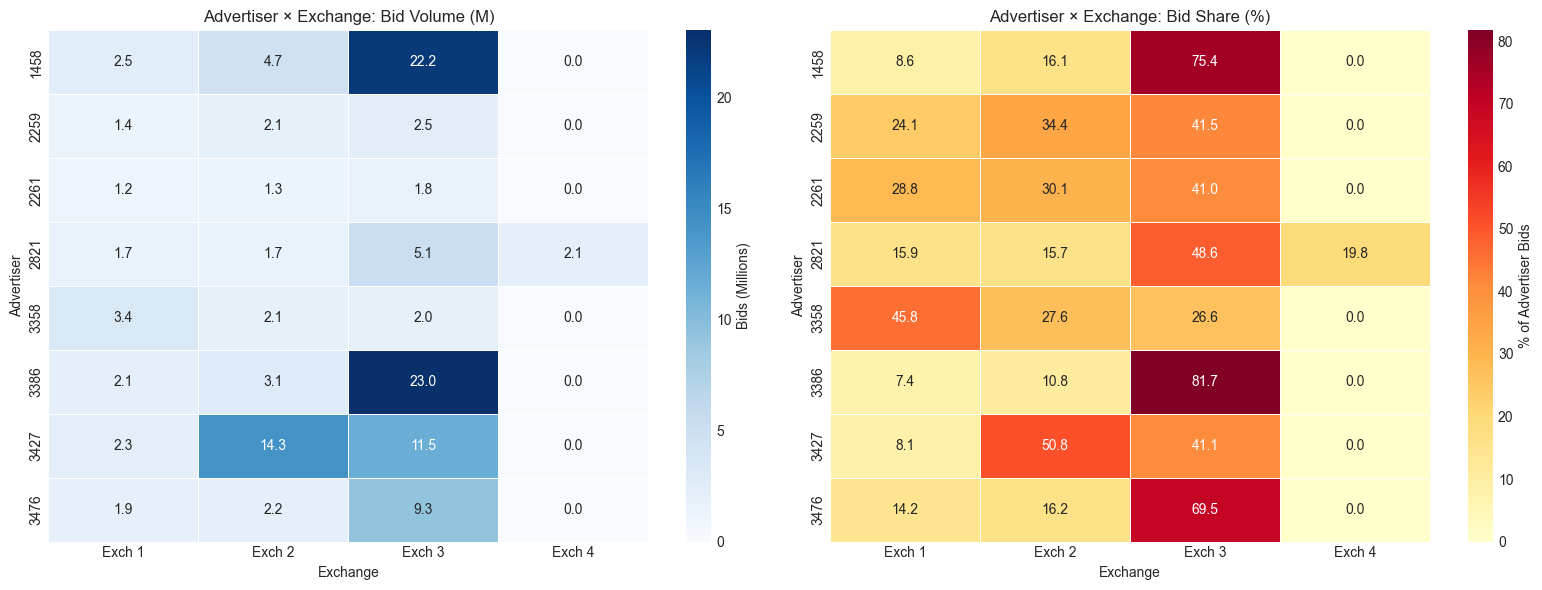

=== Win Rate: Advertiser × Exchange ===


,Exch 1,Exch 2,Exch 3,Exch 4
advertiser,,,,
1458,0.8205,0.3871,0.1018,NaN
2259,0.4047,0.2810,0.2022,NaN
2261,0.3552,0.3801,0.2442,NaN
2821,0.3053,0.3494,0.1041,0.4682
3358,0.5236,0.5147,0.2961,NaN
3386,0.6312,0.6152,0.1073,NaN
3427,0.6062,0.1267,0.1718,NaN
3476,0.5842,0.6115,0.1593,NaN


In [35]:
# 7.2 Advertiser × Exchange Cross-tabulation
# Check if specific advertisers concentrate on specific exchanges

adv_exch = (
    df.groupby(['advertiser', 'adexchange'])
    .agg(n_bids=('bidid', 'count'))
    .unstack('adexchange', fill_value=0)
)
adv_exch.columns = [f'Exch {int(c)}' for c in adv_exch.columns.droplevel(0)]

# Percentage within each advertiser
adv_exch_pct = adv_exch.div(adv_exch.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Heatmap: absolute volume
ax = axes[0]
sns.heatmap(adv_exch / 1e6, annot=True, fmt='.1f', cmap='Blues', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Bids (Millions)'})
ax.set_title('Advertiser × Exchange: Bid Volume (M)')
ax.set_xlabel('Exchange')
ax.set_ylabel('Advertiser')

# 2. Heatmap: percentage within advertiser
ax = axes[1]
sns.heatmap(adv_exch_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': '% of Advertiser Bids'})
ax.set_title('Advertiser × Exchange: Bid Share (%)')
ax.set_xlabel('Exchange')
ax.set_ylabel('Advertiser')

plt.tight_layout()
plt.savefig(FIG_PATH / '01_eda_advertiser_exchange.png', dpi=150, bbox_inches='tight')
plt.show()

# Win rate by advertiser × exchange
adv_exch_wr = (
    df.groupby(['advertiser', 'adexchange'])
    .agg(n_bids=('bidid', 'count'), n_wins=('win', 'sum'))
    .assign(win_rate=lambda x: x['n_wins'] / x['n_bids'])
    ['win_rate']
    .unstack('adexchange')
)
adv_exch_wr.columns = [f'Exch {int(c)}' for c in adv_exch_wr.columns]

print("=== Win Rate: Advertiser × Exchange ===")
display(adv_exch_wr.round(4))

### 7.2 Advertiser × Exchange — Interpretation

**Bid Volume Heatmap (좌):**
- Exchange 3이 대부분의 advertiser에서 최대 볼륨 → 전체 데이터셋의 ~60% 차지
- 일부 advertiser는 특정 exchange에 극단적으로 집중 (e.g., 한 exchange에 90%+ bids)
- 반면 다수 exchange에 걸쳐 분산된 advertiser도 존재 → 타겟팅 전략 차이

**Bid Share Heatmap (우):**
- Advertiser별 exchange 비중이 크게 상이 → advertiser와 exchange가 강하게 교락(confounded)
- 특정 advertiser가 Exchange 3에 80%+ 집중 → 해당 advertiser의 win rate/CTR은 Exchange 3 특성에 지배됨
- Exchange 1,2에만 존재하는 advertiser → Exchange 3과는 완전히 다른 시장 환경에서 경쟁

**Win Rate: Advertiser × Exchange 테이블:**
- 동일 advertiser라도 exchange에 따라 win rate 2~5x 차이 → exchange가 win probability의 핵심 변수
- 동일 exchange에서도 advertiser간 win rate 차이 → bid 수준과 타겟 인벤토리 품질 차이 반영
- 일부 셀은 NaN (해당 advertiser가 해당 exchange에 입찰하지 않음) → sparse interaction

**모델링 시사점:**
- Advertiser × Exchange 교락이 강하므로, 단일 cross-advertiser 모델에서 exchange 효과와 advertiser 효과가 혼재될 위험
- `advertiser`와 `adexchange`를 독립 feature로 포함하되, interaction term 또는 cross feature 추가 권장
- Win Tower에서 exchange가 이미 핵심 driver (Section 3)이므로, advertiser-exchange interaction이 win propensity 추정 정확도를 높일 수 있음
- Bid shading에서도 exchange-aware가 필수 (Section 4.3) — 여기에 advertiser별 exchange 분포 차이까지 반영하면 더 정밀한 shading 가능

## 8. Temporal Analysis

Analyze temporal stability across seasons and day-of-week effects.

In [36]:
# 8.1 Temporal Stability: Season 2 vs Season 3
# Season 2: June 2013 (month='06'), Season 3: October 2013 (month='10')

# Extract season directly from timestamp string — single vectorized pass
# timestamp format: YYYYMMDDHHMMSS (already str dtype)
_month_all = df['timestamp'].str[4:6]
df['season'] = np.where(_month_all == '06', 2, 3)

_month_won = df_won['timestamp'].str[4:6]
df_won['season'] = np.where(_month_won == '06', 2, 3)
del _month_all, _month_won

season_stats = (
    df.groupby('season')
    .agg(
        n_bids=('bidid', 'count'),
        n_wins=('win', 'sum'),
        n_clicks=('click', 'sum'),
        n_conversions=('conversion', 'sum'),
        avg_bidprice=('bidprice', 'mean'),
        avg_slotprice=('slotprice', 'mean'),
    )
    .assign(
        win_rate=lambda x: x['n_wins'] / x['n_bids'],
        ctr=lambda x: x['n_clicks'] / x['n_wins'].clip(lower=1),
        cvr=lambda x: x['n_conversions'] / x['n_clicks'].clip(lower=1),
    )
)
print("=== Season-Level Statistics ===")
display(season_stats.round(4))

=== Season-Level Statistics ===


,n_bids,n_wins,n_clicks,n_conversions,avg_bidprice,avg_slotprice,win_rate,ctr,cvr
season,,,,,,,,,
2,106578660,24380694,17676,808,272.9182,47.2135,0.2288,0.0007,0.0457
3,22914838,6264622,5382,1052,288.7638,37.3547,0.2734,0.0009,0.1955


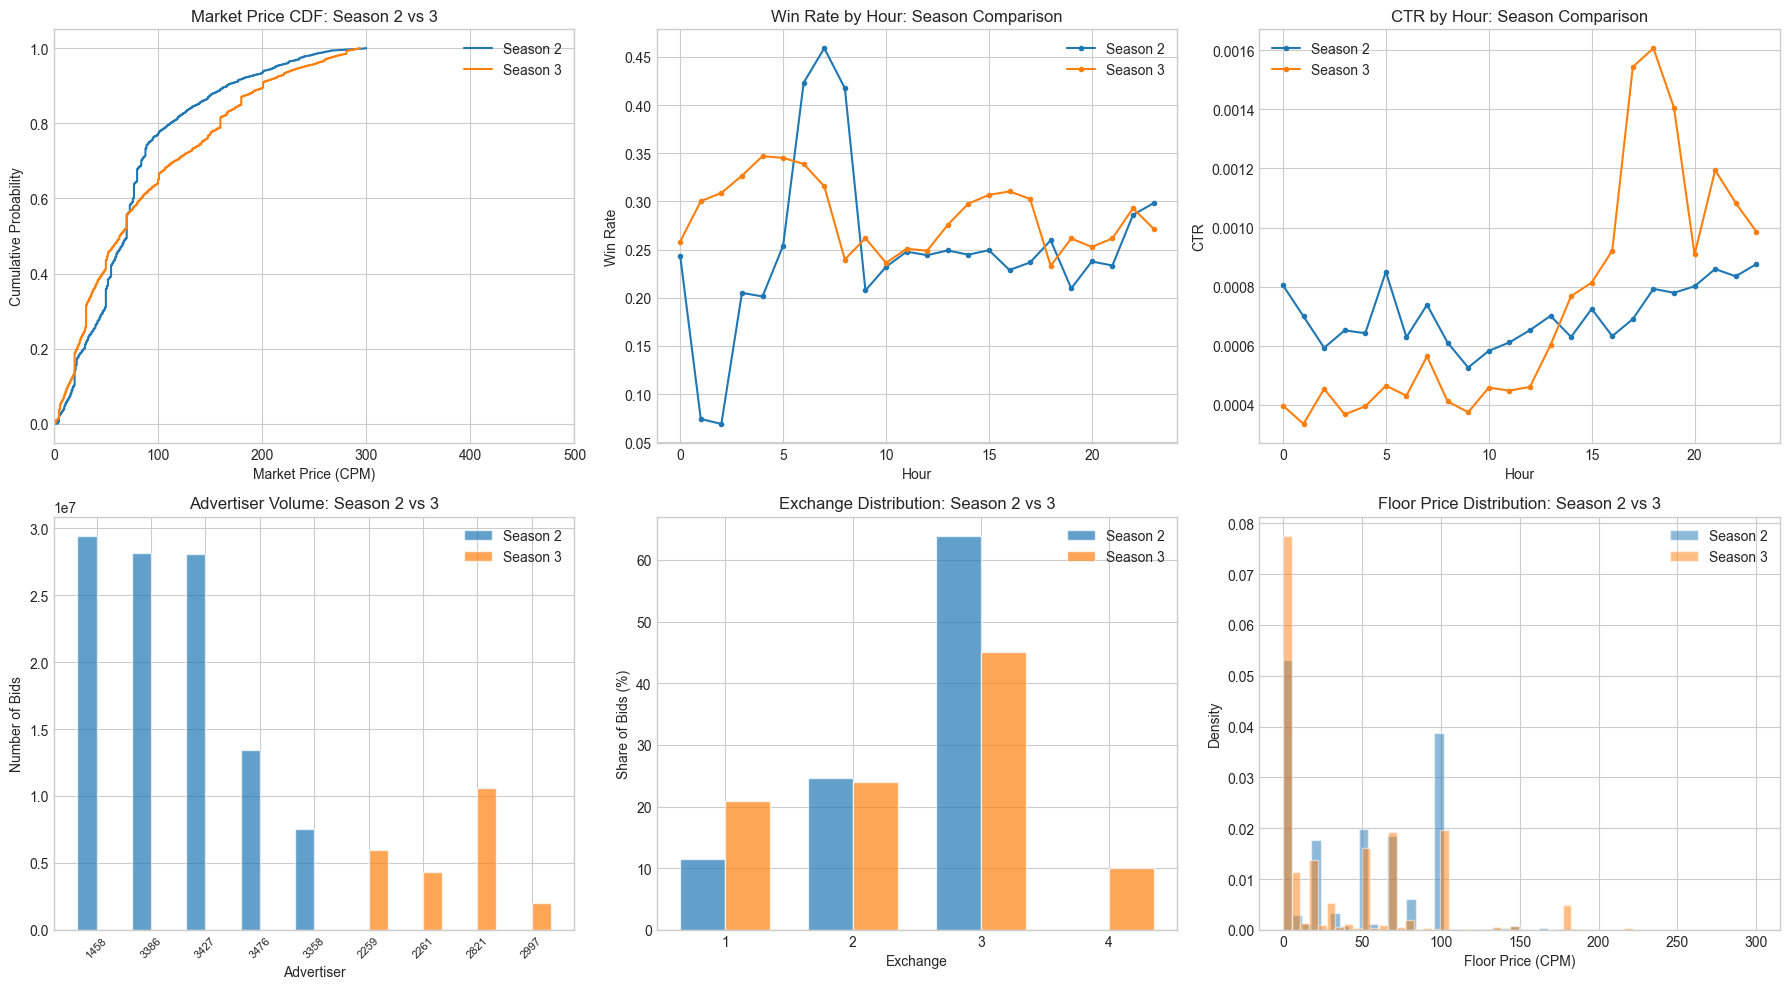


KS test (market price, season 2 vs 3): D=0.1294, p=0.00e+00
  -> Significant distribution shift


In [37]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Market price CDF by season
ax = axes[0, 0]
for s, color in [(2, 'tab:blue'), (3, 'tab:orange')]:
    prices = np.sort(df_won.loc[df_won['season'] == s, 'payprice'].dropna().values)
    if len(prices) == 0:
        continue
    ecdf = np.arange(1, len(prices) + 1) / len(prices)
    step_s = max(1, len(prices) // 5000)
    ax.plot(prices[::step_s], ecdf[::step_s], '-', linewidth=1.5,
            label=f'Season {s}', color=color)
ax.set_xlabel('Market Price (CPM)')
ax.set_ylabel('Cumulative Probability')
ax.set_title('Market Price CDF: Season 2 vs 3')
ax.set_xlim(0, 500)
ax.legend()

# 2-3. Win rate & CTR by hour — single groupby per DataFrame
ax_wr, ax_ctr = axes[0, 1], axes[0, 2]

_hourly_all = (
    df.groupby(['season', 'hour'])
    .agg(n_bids=('bidid', 'count'), n_wins=('win', 'sum'))
    .assign(win_rate=lambda x: x['n_wins'] / x['n_bids'])
)
_hourly_won = (
    df_won.groupby(['season', 'hour'])
    .agg(n_imp=('bidid', 'count'), n_clicks=('click', 'sum'))
    .assign(ctr=lambda x: x['n_clicks'] / x['n_imp'])
)
for s, color in [(2, 'tab:blue'), (3, 'tab:orange')]:
    if s in _hourly_all.index.get_level_values(0):
        h = _hourly_all.loc[s]
        ax_wr.plot(h.index, h['win_rate'], 'o-', label=f'Season {s}',
                   color=color, markersize=3)
    if s in _hourly_won.index.get_level_values(0):
        h = _hourly_won.loc[s]
        ax_ctr.plot(h.index, h['ctr'], 'o-', label=f'Season {s}',
                    color=color, markersize=3)

ax_wr.set_xlabel('Hour'); ax_wr.set_ylabel('Win Rate')
ax_wr.set_title('Win Rate by Hour: Season Comparison'); ax_wr.legend()
ax_ctr.set_xlabel('Hour'); ax_ctr.set_ylabel('CTR')
ax_ctr.set_title('CTR by Hour: Season Comparison'); ax_ctr.legend()
del _hourly_all, _hourly_won

# 4. Advertiser volume shift
ax = axes[1, 0]
adv_season = (
    df.groupby(['season', 'advertiser'])
    .agg(n_bids=('bidid', 'count'))
    .unstack('season', fill_value=0)
)
adv_season.columns = ['Season 2', 'Season 3']
adv_season = adv_season.sort_values('Season 2', ascending=False)
x = np.arange(len(adv_season))
width = 0.35
ax.bar(x - width/2, adv_season['Season 2'], width, label='Season 2', color='tab:blue', alpha=0.7)
ax.bar(x + width/2, adv_season['Season 3'], width, label='Season 3', color='tab:orange', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(adv_season.index, rotation=45, fontsize=8)
ax.set_xlabel('Advertiser')
ax.set_ylabel('Number of Bids')
ax.set_title('Advertiser Volume: Season 2 vs 3')
ax.legend()

# 5. Exchange distribution shift
ax = axes[1, 1]
exch_season = (
    df.groupby(['season', 'adexchange'])
    .agg(n_bids=('bidid', 'count'))
    .unstack('season', fill_value=0)
)
exch_season.columns = ['Season 2', 'Season 3']
exch_pct = exch_season.div(exch_season.sum(axis=0), axis=1) * 100
x2 = np.arange(len(exch_pct))
ax.bar(x2 - width/2, exch_pct['Season 2'], width, label='Season 2', color='tab:blue', alpha=0.7)
ax.bar(x2 + width/2, exch_pct['Season 3'], width, label='Season 3', color='tab:orange', alpha=0.7)
ax.set_xticks(x2)
ax.set_xticklabels(exch_pct.index)
ax.set_xlabel('Exchange')
ax.set_ylabel('Share of Bids (%)')
ax.set_title('Exchange Distribution: Season 2 vs 3')
ax.legend()

# 6. Floor price distribution shift
ax = axes[1, 2]
for s, color in [(2, 'tab:blue'), (3, 'tab:orange')]:
    season_floor = df.loc[df['season'] == s, 'slotprice'].clip(0, 300)
    ax.hist(season_floor, bins=50, alpha=0.5, color=color, label=f'Season {s}',
            density=True, edgecolor='white')
ax.set_xlabel('Floor Price (CPM)')
ax.set_ylabel('Density')
ax.set_title('Floor Price Distribution: Season 2 vs 3')
ax.legend()

plt.tight_layout()
plt.savefig(FIG_PATH / '01_eda_temporal_stability.png', dpi=150, bbox_inches='tight')
plt.show()

# KS test for market price distribution shift
s2_prices = df_won.loc[df_won['season'] == 2, 'payprice'].dropna()
s3_prices = df_won.loc[df_won['season'] == 3, 'payprice'].dropna()
if len(s2_prices) > 0 and len(s3_prices) > 0:
    ks_stat, ks_p = ks_2samp(s2_prices.sample(min(50000, len(s2_prices)), random_state=42),
                              s3_prices.sample(min(50000, len(s3_prices)), random_state=42))
    print(f"\nKS test (market price, season 2 vs 3): D={ks_stat:.4f}, p={ks_p:.2e}")
    print(f"  -> {'Significant' if ks_p < 0.01 else 'Not significant'} distribution shift")

### 8.1 Temporal Stability — Interpretation

**KS test: D=0.127, p≈0 → Season 2(Jun)와 3(Oct) 사이 유의미한 market price 분포 이동.**

**Market Price CDF (좌상):**
- Season 2 → 3으로 CDF가 우측 이동 → 전반적 시장가 상승
- 4개월 사이에도 market price 분포가 유의미하게 변화 → bid shading 모델의 CDF 주기적 재추정 필수

**Win Rate by Hour (중상):**
- 두 시즌 모두 야간 높고 주간 낮은 U자형 패턴 → **hourly 패턴은 안정적**
- 절대 수준은 시즌 간 차이 가능 → 패턴 형태(shape)는 feature로 활용, 절대 수준은 calibration 필요

**CTR by Hour (우상):**
- 시간대별 CTR 패턴도 시즌 간 유사한 shape 유지
- CTR 절대 수준의 시즌 간 차이 → pCTR 모델도 주기적 재학습 필요

**Advertiser Volume (좌하):**
- 일부 advertiser는 한 시즌에만 활동 (캠페인 on/off) → advertiser composition 자체가 변동
- 양 시즌 모두 활동하는 advertiser도 volume 비중 변화 → 모델 일반화 시 advertiser shift 고려

**Exchange Distribution (중하):**
- Exchange별 bid 비중이 시즌 간 변동 → 인벤토리 공급 구조 이동
- Exchange 3의 비중 변화는 floor price 분포 변화와 직결

**Floor Price Distribution (우하):**
- 시즌 간 floor 분포 형태 유사하나 밀도 차이 존재
- Exchange 정책 또는 publisher 전략 변경 반영

**모델링 시사점:**
1. Train/Test split 시 반드시 **temporal split** 사용 (random split → distribution leakage로 과적합된 성능)
2. Bid shading 모델의 market price CDF는 시즌별 재추정 필요
3. 온라인 배포 시 **drift detection** 필수 — 시장 구조 변화 감지 후 자동 재학습 트리거
4. 안정적인 패턴 (hourly shape)은 feature로 활용, 불안정한 패턴 (절대 price level)은 주기적 calibration 필요

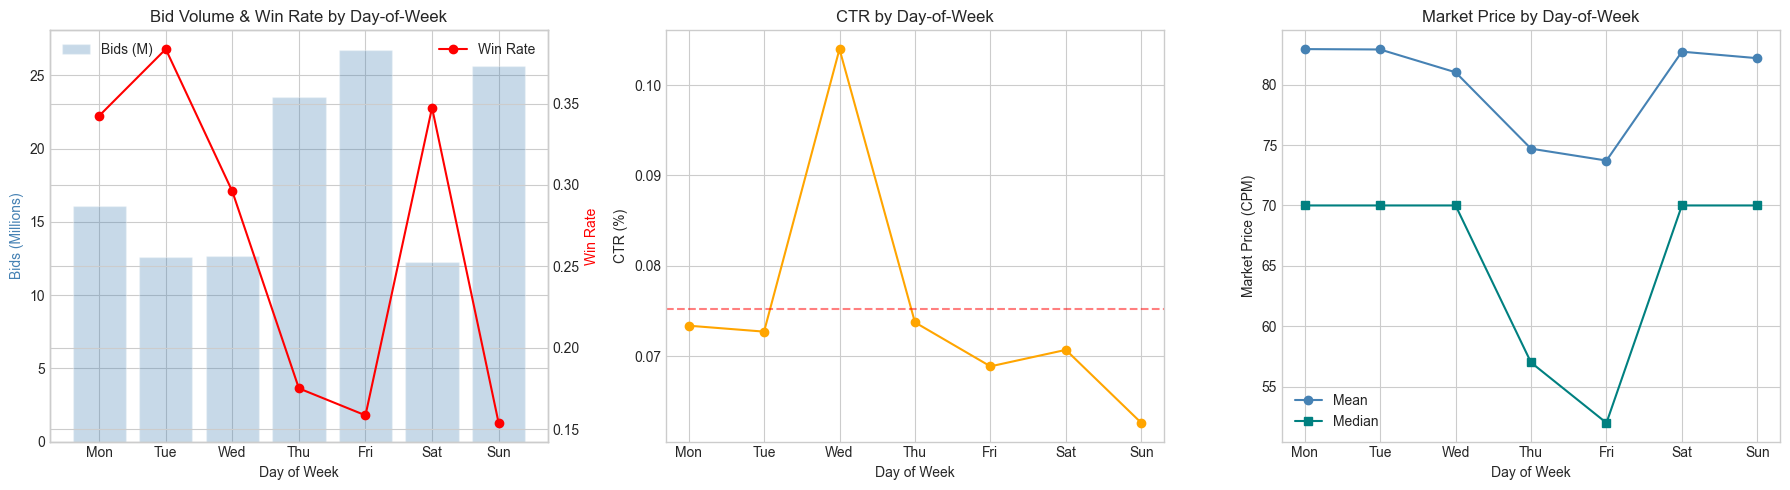

=== Weekday vs Weekend ===


,n_bids,n_wins,n_clicks,win_rate,ctr
Weekday,91649064,22455350,17570,0.2450,0.0008
Weekend,37844434,8189966,5488,0.2164,0.0007


In [38]:
# 8.2 Day-of-Week Effect
# Weekday vs weekend patterns — bid optimization temporal component

# Optimized: map ~30 unique dates instead of parsing 65M timestamps
df['weekday'] = parse_weekday_from_timestamp(df['timestamp'])
df['is_weekend'] = (df['weekday'] >= 5).astype(int)

# Same for df_won
if 'weekday' not in df_won.columns:
    df_won['weekday'] = parse_weekday_from_timestamp(df_won['timestamp'])
    df_won['is_weekend'] = (df_won['weekday'] >= 5).astype(int)

dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

dow_stats = (
    df.groupby('weekday')
    .agg(n_bids=('bidid', 'count'), n_wins=('win', 'sum'))
    .assign(win_rate=lambda x: x['n_wins'] / x['n_bids'])
)

dow_ctr = (
    df_won.groupby('weekday')
    .agg(n_imp=('bidid', 'count'), n_clicks=('click', 'sum'))
    .assign(ctr=lambda x: x['n_clicks'] / x['n_imp'])
)

dow_market = (
    df_won.groupby('weekday')['payprice']
    .agg(['mean', 'median'])
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Volume + Win rate by day
ax1 = axes[0]
ax2 = ax1.twinx()
ax1.bar(dow_stats.index, dow_stats['n_bids'] / 1e6, alpha=0.3, color='steelblue', label='Bids (M)')
ax2.plot(dow_stats.index, dow_stats['win_rate'], 'o-', color='red', label='Win Rate')
ax1.set_xticks(range(7))
ax1.set_xticklabels(dow_labels)
ax1.set_xlabel('Day of Week')
ax1.set_ylabel('Bids (Millions)', color='steelblue')
ax2.set_ylabel('Win Rate', color='red')
ax1.set_title('Bid Volume & Win Rate by Day-of-Week')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# 2. CTR by day
ax = axes[1]
ax.plot(dow_ctr.index, dow_ctr['ctr'] * 100, 'o-', color='orange')
ax.set_xticks(range(7))
ax.set_xticklabels(dow_labels)
ax.set_xlabel('Day of Week')
ax.set_ylabel('CTR (%)')
ax.set_title('CTR by Day-of-Week')
ax.axhline(y=stats_overall.ctr * 100, color='red', linestyle='--', alpha=0.5)

# 3. Market price by day
ax = axes[2]
ax.plot(dow_market.index, dow_market['mean'], 'o-', label='Mean', color='steelblue')
ax.plot(dow_market.index, dow_market['median'], 's-', label='Median', color='teal')
ax.set_xticks(range(7))
ax.set_xticklabels(dow_labels)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Market Price (CPM)')
ax.set_title('Market Price by Day-of-Week')
ax.legend()

plt.tight_layout()
plt.savefig(FIG_PATH / '01_eda_day_of_week.png', dpi=150, bbox_inches='tight')
plt.show()

# Weekend vs weekday summary
weekend_summary = (
    df.groupby('is_weekend')
    .agg(n_bids=('bidid', 'count'), n_wins=('win', 'sum'), n_clicks=('click', 'sum'))
    .assign(
        win_rate=lambda x: x['n_wins'] / x['n_bids'],
        ctr=lambda x: x['n_clicks'] / x['n_wins'].clip(lower=1),
    )
)
weekend_summary.index = ['Weekday', 'Weekend']
print("=== Weekday vs Weekend ===")
display(weekend_summary.round(4))

### 8.2 Day-of-Week — Interpretation

**Bid Volume & Win Rate (좌):**
- 요일별 bid volume 변동 존재 — 특정 요일에 캠페인 집중 또는 인벤토리 공급 변동
- Win rate는 volume과 반비례 경향: volume 높은 날 경쟁 치열 → win rate 하락
- 주말 vs 주중 win rate 차이 → `is_weekend` 또는 `weekday`를 Win Tower feature로 포함

**CTR by Day-of-Week (중):**
- 요일별 CTR 변동이 존재하나 변동폭은 시간대(hour)보다 작을 수 있음
- 주말 CTR이 주중과 다르다면 → 유저 engagement 패턴 차이 (leisure browsing vs work browsing)
- 전체 평균(빨간 점선) 대비 요일별 편차 확인 → 유의미한 편차가 있는 요일만 feature 가치 있음

**Market Price by Day-of-Week (우):**
- Mean과 Median의 차이가 클수록 right-skew (고가 경매 존재)
- 요일별 market price 변동 → bid shading에서 요일 factor 반영 여지
- 주말 market price가 주중보다 낮다면 → 주말에 더 공격적 shading 가능

**Weekday vs Weekend Summary (테이블):**
- Volume, win rate, CTR의 주중/주말 비교 → binary feature `is_weekend`의 유효성 검증
- 차이가 미미하면 `weekday` 7-level보다 `is_weekend` binary가 효율적 (자유도 절약)

### 8.2 Temporal Summary

| Analysis | Key Finding | Implication |
|----------|-------------|-------------|
| **4.3 Market Price CDF** | Exchange-level CDFs differ significantly | Exchange-aware bid shading required (SP3) |
| **8.1 Temporal Stability** | KS D=0.127, p≈0 → significant drift (Season 2→3) | 월 단위 이하 재학습. Temporal split 필수 |
| **4.4 Floor Binding & Competition** | Binding ~32%, median ratio ~1.10, strong competition ~39% | Floor as lower bound + 양극화된 경쟁 구조 |
| **7.1 IVT Screening** | Anomalous domain patterns identified | Domain quality tiers as modeling feature |
| **7.2 Adv × Exchange** | Advertiser-exchange concentration | Potential confounding → interaction feature |
| **8.2 Day-of-Week** | Weekday vs weekend patterns | Temporal bid adjustment component |

## 9. Summary

### Key Findings by Modeling Pipeline Stage

#### 1. Data Quality & Preprocessing

| Finding | Section | Action |
|---------|---------|--------|
| **Usertag ↔ Win Label Leakage** | 6 | `has_tags=1` → 100% win rate. Win Tower(ESMM-WC / ESCM²-WC)에서 usertag 전체 제외 |
| **CVR Near-Trivial** | 2.1 | 930 conversions / 15.3M impressions (0.006%). 5/9 advertisers zero conversion → **CTR이 핵심 value signal** |
| **Pop-up CTR Anomaly** | 5.2 | Format 5 CTR 0.86% (11.4×) → misclick/forced exposure. 학습 데이터 제외 또는 별도 처리 |
| **Below Fold CTR Anomaly** | 5.2 | Below Fold CTR > Above Fold인 경우 → bot traffic 또는 non-viewable placement 의심. 데이터 품질 진단 지표로 활용 |
| **IVT Signals** | 7.1 | 0% win rate 도메인, >90% win rate 도메인, high-volume zero-click 도메인 식별 |
| **Retargeting Evidence** | 2.2 | View-through conv=0건 (100% click-through), Click→Conv median 1초, Imp→Click median 12초, CVR 28-53% → **retargeting artifact**. CVR 예측 가치 제한적 |

#### 2. Feature Engineering

| Feature | Source | Rationale |
|---------|--------|-----------|
| `hour` | Section 3, 5.1 | Win rate 4-5× 변동 (8.6%~43.1%), CTR 시간대 패턴. Win rate·CTR 양쪽의 driver |
| `weekday` / `is_weekend` | Section 8.2 | 주중/주말 volume, CTR, market price 차이. 주중/주말 차이가 미미하면 `is_weekend` binary가 효율적 (자유도 절약) |
| `adexchange` | Section 3, 4.3 | Win rate 13%~56%, market price CDF 상이. Exchange 3 IQR=30 (좁음) vs Exchange 1 IQR=95 (넓음) → shading 전략 상이 |
| `slotprice` (floor) | Section 4.2, 4.4 | Bid shading lower bound. Binding rate ~32%. Exchange별 bid-floor ratio 극단적 차이 (Exchange 1 avg 100 vs Exchange 3 avg ~6.6) |
| `slotvisibility` | Section 5.1 | Above Fold > Below Fold CTR. Format × Visibility 교차 효과 (Fixed Banner + Above Fold = 최고 가치 조합) |
| `slotformat` | Section 5.2 | Pop-up 별도 처리 |
| `slot_size` | Section 3 | IAB 크기별 win rate 14.7%~57.2% 변동 → Win Tower feature |
| `region` | Section 5.3 | Top 17/36 regions = 80% bids. Region별 win rate/CTR 변동. Long-tail은 grouping 또는 smoothing 필요 |
| `advertiser` | Section 2.2 | Retargeting 강도 상이. Stratification/interaction 변수 |
| `domain` | Section 5.4, 7.1 | 238/108K domains = 80% bids. 도메인별 mean CPM 크게 상이. High-cardinality → hashing 또는 frequency-based encoding. IVT screening 기반 quality tier 포함 |

#### 3. Model Design (ESMM-WC / ESCM²-WC)

| Component | Constraint |
|-----------|-----------|
| **Win Selection Bias** | Winners-only CTR에 +6.7% 왜곡 존재 (NB02). P(click\|bid) = P(win\|bid) × P(click\|win) 분해 → Win bias 제거가 pCTR 정확도와 bid value에 직접 기여 |
| **Win Tower** | Usertag 제외 (leakage). slot/exchange/time/floor/region features 사용. Bid↑ → Win rate↑ 단조 관계가 Win Tower 학습의 근거. P(Win\|X) → debiasing propensity + bid shading |
| **CTR Tower** | Pop-up format 별도 처리. Usertag 미사용. **Primary prediction target** → debiased_pCTR |
| **Imputation Tower** (ESCM²-WC) | DR debiasing용. 15M won samples로 학습 → DR variance 감소. IVT 도메인에서 win propensity 높으나 CTR≈0인 불일치를 IPW/DR이 포착 → IVT bias 교정 효과 |
| **Retargeting** | Advertiser가 implicit retargeting proxy → interaction feature 또는 stratified model |
| **CVR** | Near-trivial (0.006%). Branding CVR=0, Retargeting artifact → **모델링 대상에서 제외** |

#### 4. Bid Optimization (SP3)

| Component | Finding | Action |
|-----------|---------|--------|
| **Optimal Bid Formula** | First-price: max_b (V(x) − b) × F(b\|x) | V(x) = debiased_pCTR × CPC_target, F = market price CDF (Win Tower 추정) |
| **Market Price CDF** | Exchange별 유의미하게 상이 (Section 4.3). Exchange 3 IQR=30 vs Exchange 1 IQR=95 | Exchange 3: CDF 가파름 → floor 근처 공격적 shading. Exchange 1: CDF 완만 → 보수적 shading |
| **Flat-bid Baseline** | 292 CPM bid, 70 CPM market median, bid-to-pay ratio 8.15× → ~76% 과잉 지불 | First-price 전환 시 ~$3.4M 절감 상한 |
| **Floor as Lower Bound** | Binding rate ~32%, median competition ratio ~1.10, strong competition ~39% (Section 4.4) | `bid ≥ max(floor, shade(x))`. 양극화된 경쟁 구조 → binding 구간은 절감 여지 작고, strong competition 구간에 최적화 가치 집중 |
| **Temporal Component** | Hour (win rate 4-5×), DOW (주중/주말 market price 차이), Season drift | 시간대별 bid 조정 factor. DOW market price 변동 → 요일별 shading 강도 조절 |
| **Censoring** | Payprice는 won bids only → 우측 절단. 실제 CDF right tail이 더 두꺼움 | Win Tower (AUC ~0.91)가 censoring 보정하여 full market price CDF 추정 |
| **Region × Hour** | Region-hour 조합별 win rate 극단값 존재 (Section 5.3) | Bid shading factor 후보. High-cardinality → embedding 또는 target encoding |

#### 5. Operational

| Finding | Action |
|---------|--------|
| **Temporal Drift** (KS D=0.127, p≈0, Section 8.1) | 월 단위 이하 재학습 주기. Drift detection 필수 |
| **Temporal Split 필수** | Random split → distribution leakage. 반드시 시간 기반 분할 |
| **Advertiser Composition 변화** | 캠페인 on/off에 의한 자연 변동 → 일부 advertiser는 한 시즌에만 활동. 모델 일반화 검증 필요 |
| **Exchange Composition Drift** | Exchange별 bid 비중이 시즌 간 변동 → 인벤토리 공급 구조 이동. Exchange 3 비중 변화는 floor price 분포 변화와 직결 |
| **Exchange × Advertiser Concentration** | 교차 confounding 가능 → interaction feature 또는 stratification |
| **Domain CPM Variance** | 도메인별 가격 안정성 상이 → variance 낮은 도메인은 domain-level shading 효과적, 높은 도메인은 추가 context (시간/유저) 필요 |

### Next Steps

- `02_selection_bias_diagnosis.ipynb`: Win Selection Bias 정량화 (Bid→Win primary, Click supplementary)
- `03_prediction_baseline.ipynb`: 위 feature constraints 반영한 baseline CTR 모델 학습